# Project 1: Market Risk — VaR, ES, and Copulas

**Names of all group members:**
- Mahe Velay (mahe.velay@epfl.ch)
- Adelaïde Robert (adelaide.robert@epfl.ch)
- Timothée Pottié (timothee.pottie@epfl.ch)


---

## 0) Setup

Creates necessary folders and sets hyperparameters for the project.

In [1]:
# If a package import fails, install it in your environment, e.g.:
# %pip install yfinance arch copulae statsmodels seaborn

import os
import numpy as np
import copulae
import pandas as pd
import scipy.stats as stats
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import jarque_bera
from scipy.stats import t
from statsmodels.distributions.empirical_distribution import ECDF
from statsmodels.tsa.stattools import pacf
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox







# your own script with helper functions, if any
# we prefer to introduce helpers chronologyally as they appear in the code for understanding purpose
# import utils as U
# our imports for simplicity
from scipy.stats import chi2

# Locate the Project 1 directory to this notebook's working directory
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / 'data'
OUT_DIR = PROJECT_DIR / 'output'
for d in [DATA_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Parameters
TICKERS = ['AAPL', 'META', 'JPM']
START = '2023-01-01'
END = '2025-06-30'
WINDOW = 252                        # rolling/first-window length in periods (days)
ALPHAS = [0.95, 0.99]
np.random.seed(0)

print('Project dir:', PROJECT_DIR)
print('Output ->', OUT_DIR)

Project dir: /Users/timo/Documents/Finance/QRM_P1
Output -> /Users/timo/Documents/Finance/QRM_P1/output


Download and save Adjusted Close for the tickers over the given range into `data/` (CSV per ticker).

In [2]:
import yfinance as yf

print('Downloading data to', DATA_DIR)
for t in TICKERS:
    print(f'  -> {t}')
    df = yf.download(t, start=START, end=END, progress=False, auto_adjust=False)
    if df.empty:
        print(f'     Warning: no data for {t}')
        continue
    out = df.reset_index()
    out = out[['Date', 'Adj Close']]
    out.to_csv(DATA_DIR / f'{t}.csv', index=False)
print('Done.')

  -> AAPL
  -> META
  -> JPM
Done.


Now, load the data back from CSVs

In [3]:
files = [f for f in os.listdir(DATA_DIR) if f.lower().endswith('.csv')]
frames = []
for f in files:
    p = os.path.join(DATA_DIR, f)
    df = pd.read_csv(p, parse_dates=['Date'])
    df = df[['Date', 'Adj Close']]
    # Coerce to numeric and drop malformed rows
    df['Adj Close'] = pd.to_numeric(df['Adj Close'], errors='coerce')
    df = df.dropna(subset=['Date', 'Adj Close'])
    df = df.rename(columns={'Adj Close': f.split('.')[0]})
    df = df.set_index('Date').sort_index()
    frames.append(df)
prices = pd.concat(frames, axis=1).dropna(how='all')

print(prices.head(2))

                  JPM        META        AAPL
Date                                         
2023-01-03  125.49221  123.975716  123.211197
2023-01-04  126.66246  126.589615  124.482040


## 1) Empirical stylized facts


1.  Construct daily log-returns for AAPL, MSFT, JPM; plot series and comment on trends/volatility.
2.  Estimate correlation functions of returns and absolute returns across assets and lags 0–25; comment.
3.  QQ plots vs Normal; perform Jarque–Bera test and discuss normality.


## a)

In [4]:
# Check for missing values
prices.isna().sum()

JPM     0
META    0
AAPL    0
dtype: int64

In [5]:
# Compute log-returns
log_ret = np.log(prices / prices.shift(1)).dropna()
print(log_ret.head(2))

                 JPM      META      AAPL
Date                                    
2023-01-04  0.009282  0.020865  0.010262
2023-01-05 -0.000222 -0.003382 -0.010661


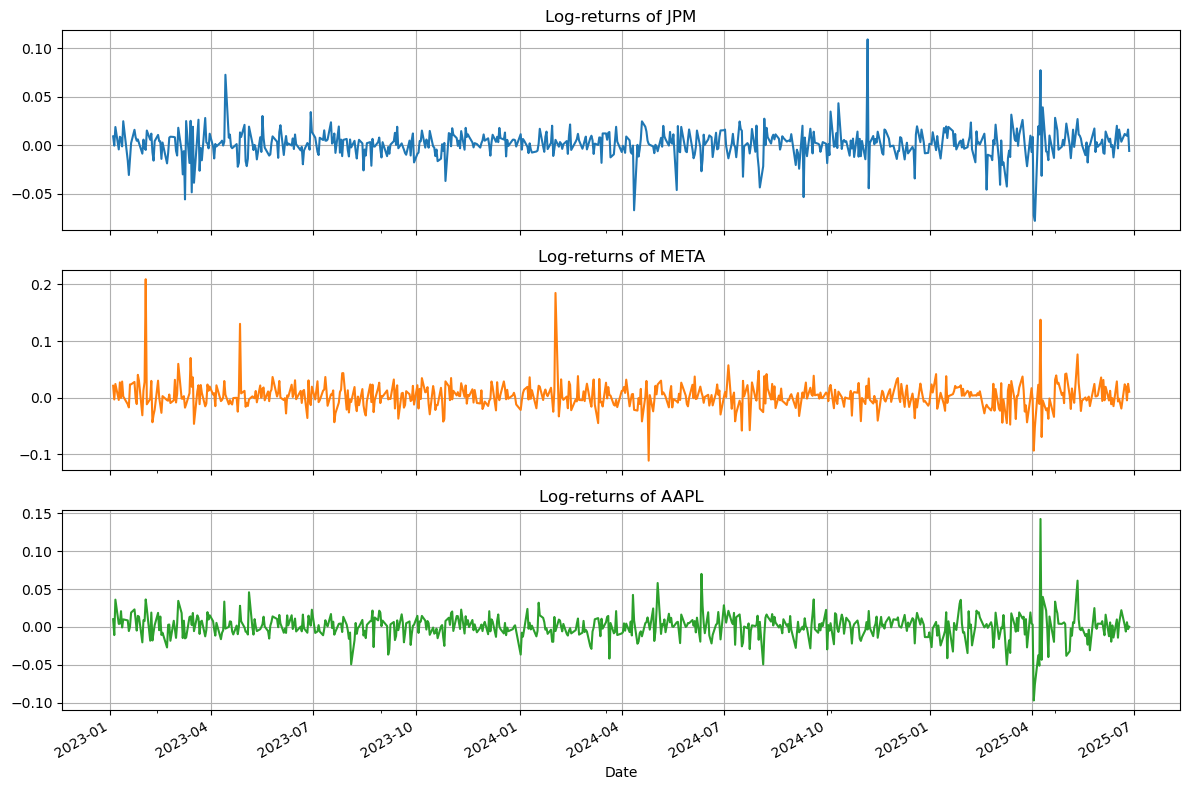

In [6]:
ax = log_ret.plot(subplots=True, figsize=(12, 8), legend=False, grid=True)
for a, col in zip(ax, log_ret.columns):
    a.set_title(f'Log-returns of {col}')
ax[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


- Log-returns fluctuate around zero → no visible trend (mean ~ 0)
- Volatility is not constant → clear volatility clustering
- Occasional large spikes → evidence of fat tails / extreme events
- META shows highest overall volatility; JPM the lowest
- Time-varying volatility suggests need for GARCH-type models

## b)

In [7]:
# cross correlation function 
def cross_correlation_lags(x, y, max_lag):
    lags = range(0, max_lag + 1)
    corr_values = [x.corr(y.shift(l)) for l in lags]
    return pd.Series(corr_values, index=lags, name="cross_corr")

#Autocorrelation function 
def ACF(x, max_lags):
    lags = range(0, max_lags + 1)
    acf_values = [x.corr(x.shift(l)) for l in lags]
    return pd.Series(acf_values, index=lags, name="autocorr")

### Cross-correlation

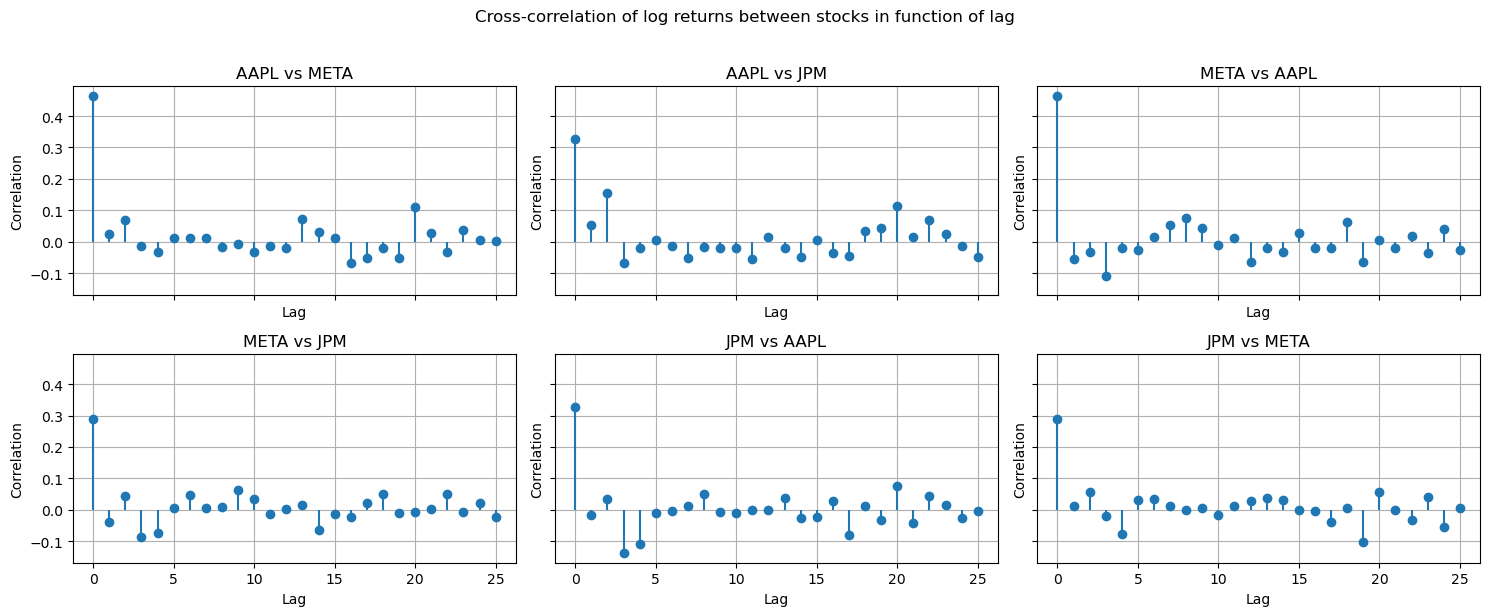

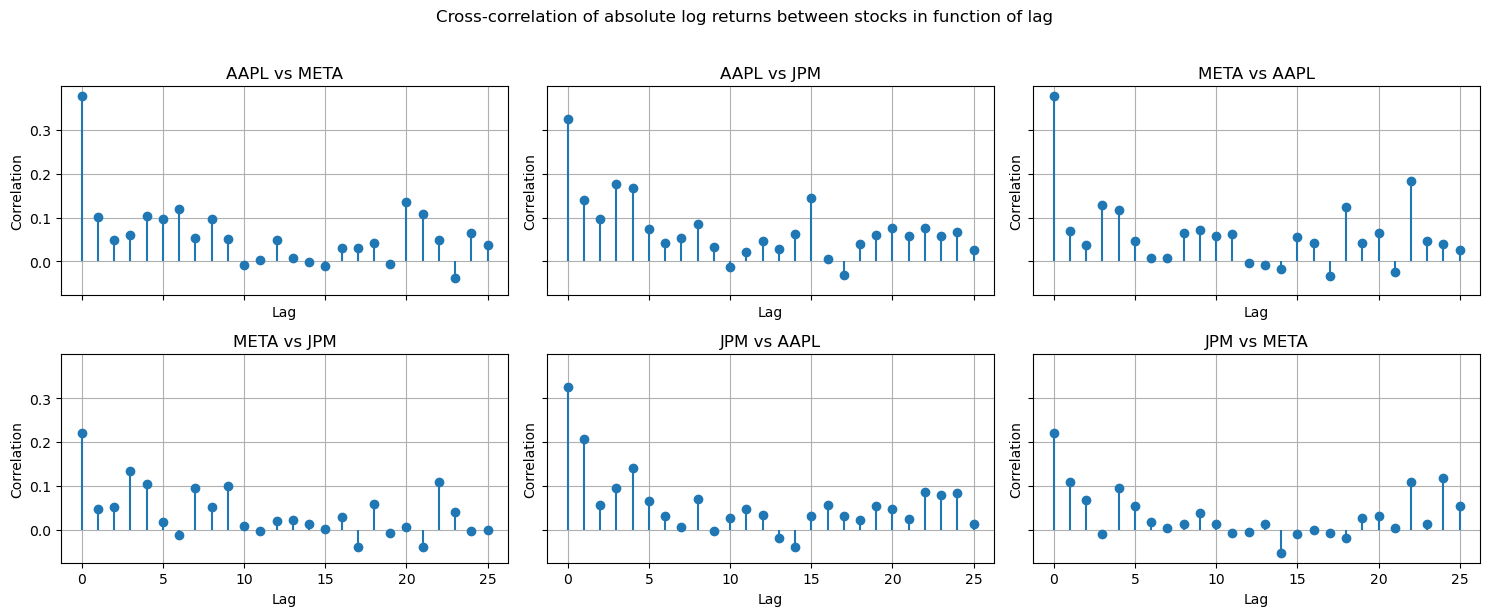

In [8]:
# all possible pairs of tickers
pairs = [(t1, t2) for t1 in TICKERS for t2 in TICKERS if t1 != t2]

# Plotting cross-correlation for log_returns 
fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True, sharey=True)
axes = axes.flatten() 

for ax, (t1, t2) in zip(axes, pairs):
    ccl = cross_correlation_lags(log_ret[t1], log_ret[t2], max_lag=25)
    ax.stem(ccl.index, ccl.values, basefmt=' ')
    ax.set_title(f'{t1} vs {t2}')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Correlation')
    ax.grid(True)

plt.suptitle('Cross-correlation of log returns between stocks in function of lag', y=1.02)
plt.tight_layout()
plt.show()

# plotting cross-correlation for absolute log_returns
fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True, sharey=True)
axes = axes.flatten() 

for ax, (t1, t2) in zip(axes, pairs):
    ccl = cross_correlation_lags(log_ret[t1].abs(), log_ret[t2].abs(), max_lag=25)
    ax.stem(ccl.index, ccl.values, basefmt=' ')
    ax.set_title(f'{t1} vs {t2}')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Correlation')
    ax.grid(True)

plt.suptitle('Cross-correlation of absolute log returns between stocks in function of lag', y=1.02)
plt.tight_layout()
plt.show()





### Autocorrelation

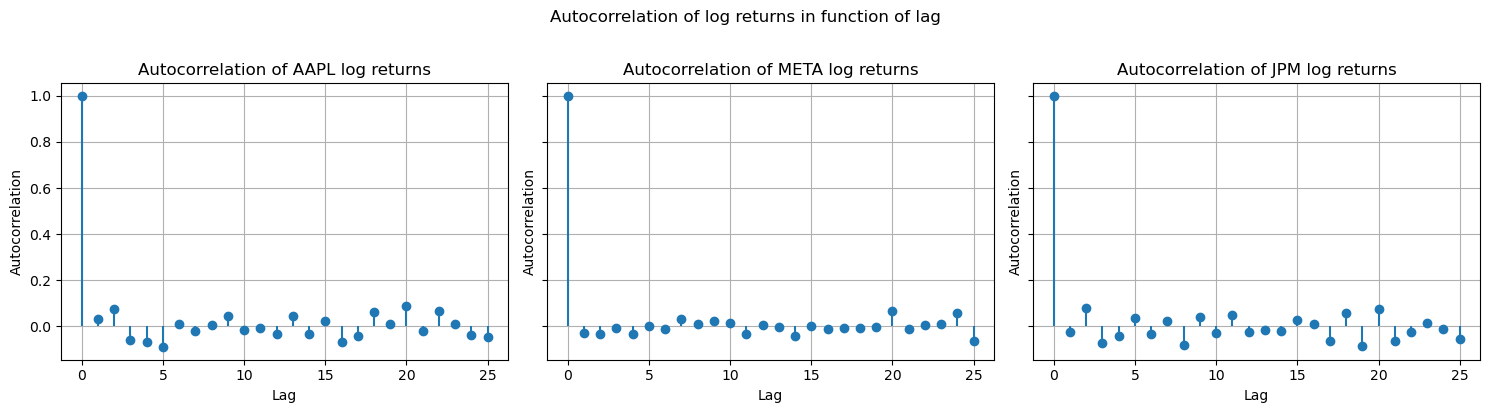

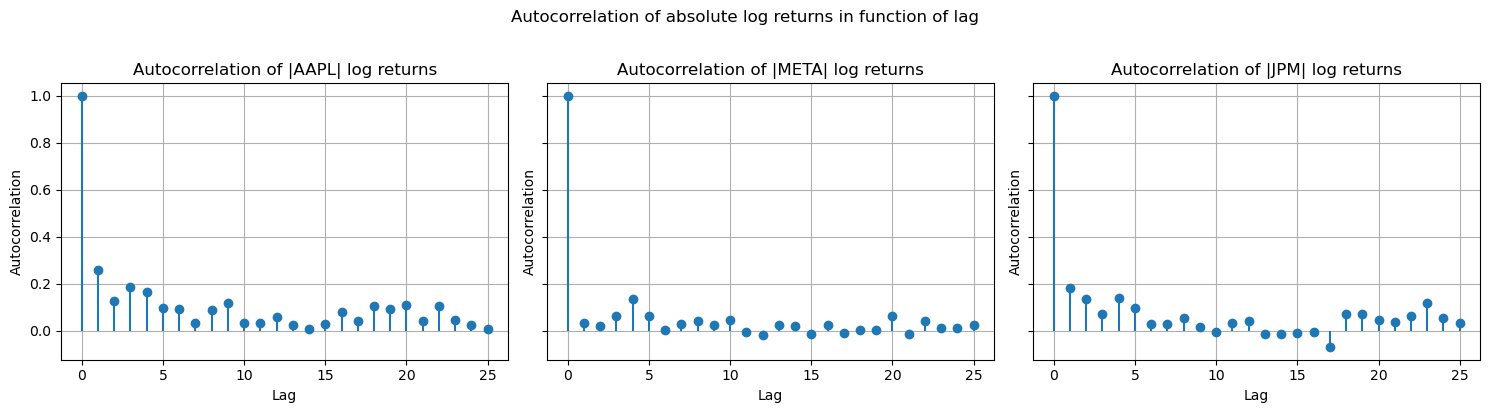

In [9]:
# Plotting autocorrelation for log_returns
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, ticker in zip(axes, TICKERS):
    acl = ACF(log_ret[ticker], max_lags=25)
    ax.stem(acl.index, acl.values, basefmt=' ')
    ax.set_title(f'Autocorrelation of {ticker} log returns')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.grid(True)
plt.suptitle('Autocorrelation of log returns in function of lag', y=1.02)
plt.tight_layout()
plt.show()

# Plotting autocorrelation for absolute log_returns
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, ticker in zip(axes, TICKERS ):
    acl = ACF(log_ret[ticker].abs(), max_lags=25)
    ax.stem(acl.index, acl.values, basefmt=' ')
    ax.set_title(f'Autocorrelation of |{ticker}| log returns')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.grid(True)
plt.suptitle('Autocorrelation of absolute log returns in function of lag', y=1.02)
plt.tight_layout()
plt.show()

- Volatility clustering: strong autocorrelation in |returns| → volatility is persistent.
- Linear dependence: raw returns show near-zero autocorrelation → no predictability.
- Cross-asset linkages: strong contemporaneous correlations (esp. META–AAPL), but lagged cross-correlations drop to zero → no lead–lag effects.

### QQ-Plot

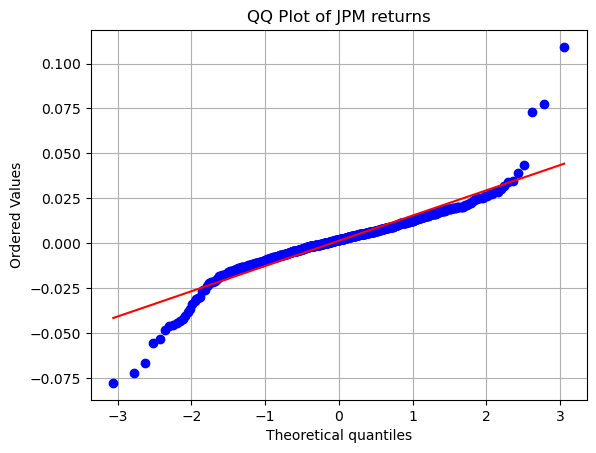

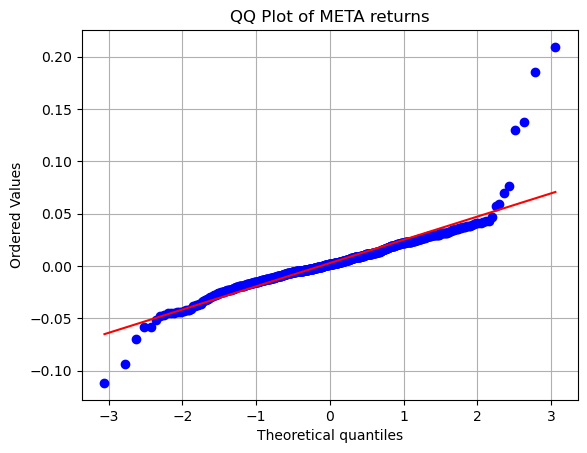

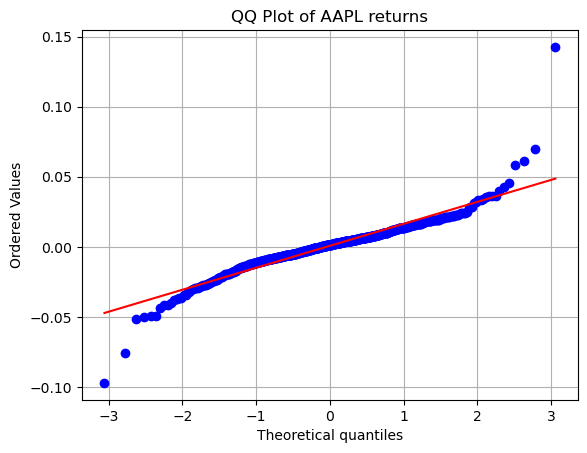

In [10]:
for col in log_ret.columns:
    stats.probplot(log_ret[col], dist="norm", plot=plt)
    plt.title(f"QQ Plot of {col} returns")
    plt.grid(True)
    plt.show()

The QQ-plots show clear deviations from the normal line in both tails, indicating that all three assets exhibit heavy-tailed return distributions. While the central quantiles roughly follow the Gaussian fit, the extreme quantiles diverge substantially, providing strong visual evidence against normality.

### Jarque–Bera test

In [11]:
for col in log_ret.columns:
    stat, p = jarque_bera(log_ret[col])
    print(f"{col}: JB={stat:.2f}, p-value={p:.4g}")

JPM: JB=2203.52, p-value=0
META: JB=7608.75, p-value=0
AAPL: JB=3619.28, p-value=0


The Jarque–Bera test confirms this: all assets display extremely large JB statistics with p-values equal to zero, leading to a decisive rejection of normality. Together, these results show that returns are fat-tailed and that Gaussian-based risk measures would underestimate tail risk.

## 2) First-window modeling: VaR, ES, and distributions

Use the first estimation window W (days) on each asset separately with losses L = −R.
Compare: 

- historical,
- Gaussian,
- Student-t,
- AR(p)+GARCH(1,1) with Normal/Student-t,
- Filtered Historical Simulation (FHS).

### Fitting of the different models 

In [12]:
def tail_mean_es(x, var_value):
    """
    ES estimator = mean of x knowing x >= VaR. If tail empty, returns VaR.
    """
    x = np.asarray(x, dtype=float)
    tail = x[x >= var_value]
    return float(tail.mean()) if tail.size > 0 else float(var_value)


# ============================================================
# Historical Simulation  (on LOSSES)
# ============================================================

def forecast_hs(L_window, alpha, quantile_method="weibull"):
    """
    Inputs:
      L_window: pd.Series of losses (length W)
      alpha: confidence level (0.95 or 0.99)
    Outputs:
      (VaR, ES, params) where params is used later for simulation in Z1.
    """
    x = np.asarray(pd.Series(L_window).dropna().values, dtype=float)
    var = np.quantile(x, alpha, method=quantile_method)
    es = tail_mean_es(x, var)
    params = {"sample_losses": x}  # for resampling later
    return float(var), float(es), params

def simulate_hs(params, size, rng):
    """
    Simulate 1-step losses from HS by bootstrap resampling.
    """
    x = params["sample_losses"]
    return rng.choice(x, size=int(size), replace=True)


# ============================================================
# Gaussian  (fit on LOSSES)
# ============================================================

def forecast_gaussian(L_window, alpha):
    x = np.asarray(pd.Series(L_window).dropna().values, dtype=float)
    mu, sigma = stats.norm.fit(x)
    sigma = float(sigma) if float(sigma) > 0 else float(np.std(x, ddof=1) if len(x) > 1 else 1e-12)

    z = norm.ppf(alpha)
    var = mu + sigma * z
    es = mu + sigma * norm.pdf(z) / (1.0 - alpha)

    params = {"mu": float(mu), "sigma": float(sigma)}
    return float(var), float(es), params

def simulate_gaussian(params, size, rng):
    mu, sigma = params["mu"], params["sigma"]
    return mu + sigma * rng.standard_normal(size=int(size))


# ============================================================
# Student-t  (fit on LOSSES)
# ============================================================

def forecast_student_t(L_window, alpha):
    x = np.asarray(pd.Series(L_window).dropna().values, dtype=float)
    nu, mu, sigma = stats.t.fit(x)
    nu = float(nu); mu = float(mu); sigma = float(sigma) if float(sigma) > 0 else 1e-12

    q = stats.t.ppf(alpha, df=nu)
    pdf_q = stats.t.pdf(q, df=nu)

    var = mu + sigma * q

    # ES exists only when nu > 1
    if nu <= 1:
        es = np.inf
    else:
        es = mu + sigma * pdf_q * (nu + q**2) / ((1.0 - alpha) * (nu - 1.0))

    params = {"nu": nu, "mu": mu, "sigma": sigma}
    return float(var), float(es), params


def simulate_student_t(params, size, rng):
    nu, mu, sigma = params["nu"], params["mu"], params["sigma"]
    return mu + sigma * rng.standard_t(df=nu, size=int(size))


# ============================================================
# PACF-based AR order selection
#   Computes PACF, identifies significant lags, and selects the
#   AR order as the first sequence of consecutive significant lags.
# ============================================================

def PACF_with_order(x, max_lags, alpha, plot=True):
    """
    Computes the PACF of a time series, checks which lags are significantly different
    from zero, and automatically selects an AR order based on the first sequence of
    consecutive significant partial autocorrelations.
    """

    pacf_vals, confint = pacf(x, nlags=max_lags, alpha=1-alpha, method= "ywmle")
    lags = np.arange(len(pacf_vals))

    # significant if CI does NOT contain 0
    sig_mask = (confint[:, 0] > 0) | (confint[:, 1] < 0)
    sig_mask[0] = False  # ignore lag 0

    # count how many consecutive lags starting from 1 are significant 
    p = 0
    for lag in range(1, len(sig_mask)):
        if sig_mask[lag]:
            p += 1
        else:
            break

    # Plot integrated in the PACF function
    if plot:
        plt.figure(figsize=(8, 4))
        markerline, stemlines, baseline = plt.stem(lags, pacf_vals, basefmt=" ")
        plt.setp(stemlines, linewidth=1.0)

        # horizontal axis at 0
        plt.hlines([0], 0, max_lags, colors="k")

        upper_bound = confint[1, 1]
        lower_bound = confint[1, 0]
        plt.axhline(upper_bound, linestyle="--", linewidth=0.8)
        plt.axhline(lower_bound, linestyle="--", linewidth=0.8)

        if p > 0:
            plt.axvline(p, color="red", linestyle="--", alpha=0.7,
                        label=f"selected p = {p}")
            plt.legend()

        plt.xlabel("Lag")
        plt.ylabel("PACF")
        plt.title(f"PACF (selected p = {p}) - Alpha = {alpha}")
        plt.xlim(-0.5, max_lags + 0.5)
        plt.tight_layout()
        plt.show()

    return p, pacf_vals, confint


def simulate_student_t(params, size, rng):
    nu, mu, sigma = params["nu"], params["mu"], params["sigma"]
    return mu + sigma * rng.standard_t(df=nu, size=int(size))


# ============================================================
# AR(p)-GARCH(1,1) Gaussian innovations (fit on RETURNS)
#     We forecast distribution of next-day LOSS:
#       R_{t+1}|F_t ~ N(mu_next, sigma_next^2)
#       L_{t+1} = -R_{t+1} ~ N(-mu_next, sigma_next^2)
# ============================================================

def fit_ar_garch_gaussian(r_window, p, scale=100.0, disp="off"):
    """
    Fit AR(p)-GARCH(1,1) with normal innovations on RETURNS (scaled by 'scale').
    Returns 'res' (arch_model fit result).
    """
    r = np.asarray(pd.Series(r_window).dropna().values, dtype=float)
    r_s = r * float(scale)
    am = arch_model(r_s, mean="ARX", lags=int(p), vol="GARCH", p=1, q=1, dist="normal")
    res = am.fit(disp=disp)
    return res


def garch_one_step_mu_sigma(res, scale=100.0):
    """
    Extract 1-step ahead forecast of RETURN mean and std (de-scaled).
    """
    f = res.forecast(horizon=1, reindex=False)
    mu_next_s = float(f.mean.values[-1, 0])
    var_next_s = float(f.variance.values[-1, 0])

    mu_next = mu_next_s / float(scale)
    sigma_next = np.sqrt(max(var_next_s, 0.0)) / float(scale)
    sigma_next = float(sigma_next) if sigma_next > 0 else 1e-12
    return float(mu_next), float(sigma_next)

def forecast_ar_garch_gaussian_from_mu_sigma(mu_next, sigma_next, alpha):
    """
    Compute VaR/ES for LOSS using the predicted N(-mu_next, sigma_next^2).
    """
    z = norm.ppf(alpha)
    var = (-mu_next) + sigma_next * z
    es = (-mu_next) + sigma_next * norm.pdf(z) / (1.0 - alpha)
    params = {"mu_next": float(mu_next), "sigma_next": float(sigma_next)}
    return float(var), float(es), params

def simulate_ar_garch_gaussian(params, size, rng):
    """
    Simulate 1-step losses under predicted Gaussian conditional distribution.
    """
    mu_next, sigma_next = params["mu_next"], params["sigma_next"]
    r_sim = mu_next + sigma_next * rng.standard_normal(size=int(size))
    return -r_sim # "-" to have the result on LOSSES


# ================================================================
# Filtered Historical Simulation (FHS) (using SAME GARCH fit)
# =================================================================

def prepare_std_resid_pool(res):
    """
    Return standardized residuals z_t (mean0,var1) as numpy array for bootstrap.
    """
    z = np.asarray(pd.Series(res.std_resid).dropna().values, dtype=float)
    if z.size == 0:
        raise ValueError("No standardized residuals from this GARCH fit.")
    z = (z - z.mean()) / z.std(ddof=1) #ddof=1 for the non-biased std
    return z


def forecast_fhs_from_res(res, alpha, M=20000, random_state=42, scale=100.0, quantile_method="weibull"):
    """
    Build FHS 1-step loss distribution:
      L = -(mu_next + sigma_next * z*),  z* resampled from standardized residuals pool.
    Returns (VaR, ES, params), where params stores (mu_next, sigma_next, z_pool).
    """
    rng = np.random.default_rng(int(random_state))
    mu_next, sigma_next = garch_one_step_mu_sigma(res, scale=scale)
    z_pool = prepare_std_resid_pool(res)

    z_star = rng.choice(z_pool, size=int(M), replace=True)
    # hygiene (optional but stable)
    if len(z_star) > 1:
        z_star = (z_star - z_star.mean()) / z_star.std(ddof=1)

    r_sim = mu_next + sigma_next * z_star
    L_sim = -r_sim

    var = np.quantile(L_sim, alpha, method=quantile_method)
    es = tail_mean_es(L_sim, var)

    params = {"mu_next": float(mu_next), "sigma_next": float(sigma_next), "z_pool": z_pool}
    return float(var), float(es), params


def simulate_fhs(params, size, rng):
    mu_next, sigma_next = params["mu_next"], params["sigma_next"]
    z_pool = params["z_pool"]
    z_star = rng.choice(z_pool, size=int(size), replace=True)
    if len(z_star) > 1:
        z_star = (z_star - z_star.mean()) / z_star.std(ddof=1)
    r_sim = mu_next + sigma_next * z_star
    return -r_sim

In [13]:
W = 252
max_lags = 25
alphas = [0.95, 0.99]
results = []

### Historical Simulation

In [14]:
for ticker in TICKERS:
    print(f"\nAsset: {ticker}")
    for alpha in alphas:
        VaR_hs, ES_hs, param_hs = forecast_hs(L_window=-log_ret[ticker].iloc[:W], alpha=alpha)
        print(f"  alpha = {alpha:.2f} :  VaR = {VaR_hs:.6f}, ES = {ES_hs:.6f}")
        
        results.append({'method': 'HS','ticker': ticker,'alpha': alpha,'VaR': VaR_hs,'ES': ES_hs})


Asset: AAPL
  alpha = 0.95 :  VaR = 0.017909, ES = 0.027557
  alpha = 0.99 :  VaR = 0.036446, ES = 0.042830

Asset: META
  alpha = 0.95 :  VaR = 0.027839, ES = 0.036607
  alpha = 0.99 :  VaR = 0.043652, ES = 0.045113

Asset: JPM
  alpha = 0.95 :  VaR = 0.018842, ES = 0.031276
  alpha = 0.99 :  VaR = 0.043159, ES = 0.052027


### Gaussian

In [15]:
for ticker in TICKERS:
    print(f"\nAsset: {ticker}")
    for alpha in alphas:
        VaR_gauss, ES_gauss, param_gauss = forecast_gaussian(L_window=-log_ret[ticker].iloc[:W], alpha=alpha)
        print(f"  alpha = {alpha:.2f} :  VaR = {VaR_gauss:.6f}, ES = {ES_gauss:.6f} (Gaussian fit : mu={param_gauss['mu']:.6f}, sigma={param_gauss['sigma']:.6f})")
        
        results.append({'method': 'Gaussian','ticker': ticker,'alpha': alpha,'VaR': VaR_gauss,'ES': ES_gauss})


Asset: AAPL
  alpha = 0.95 :  VaR = 0.019421, ES = 0.024738 (Gaussian fit : mu=-0.001509, sigma=0.012724)
  alpha = 0.99 :  VaR = 0.028092, ES = 0.032404 (Gaussian fit : mu=-0.001509, sigma=0.012724)

Asset: META
  alpha = 0.95 :  VaR = 0.035232, ES = 0.045215 (Gaussian fit : mu=-0.004061, sigma=0.023889)
  alpha = 0.99 :  VaR = 0.051512, ES = 0.059608 (Gaussian fit : mu=-0.004061, sigma=0.023889)

Asset: JPM
  alpha = 0.95 :  VaR = 0.020292, ES = 0.025723 (Gaussian fit : mu=-0.001085, sigma=0.012996)
  alpha = 0.99 :  VaR = 0.029149, ES = 0.033553 (Gaussian fit : mu=-0.001085, sigma=0.012996)


### Student-T

In [16]:
for ticker in TICKERS:
    print(f"\nAsset: {ticker}")
    for alpha in alphas:
        VaR_stud, ES_stud, param_stud = forecast_student_t(L_window=-log_ret[ticker].iloc[:W], alpha=alpha)
        print(f"  alpha = {alpha:.2f} :  VaR = {VaR_stud:.6f}, ES = {ES_stud:.6f} (student fit : nu ={param_stud['nu']:.6f}, mu={param_stud['mu']:.6f}, sigma={param_stud['sigma']:.6f})")
        
        results.append({'method': 'Student-t','ticker': ticker,'alpha': alpha,'VaR': VaR_stud,'ES': ES_stud})


Asset: AAPL
  alpha = 0.95 :  VaR = 0.018856, ES = 0.026424 (student fit : nu =6.927434, mu=-0.001537, sigma=0.010747)
  alpha = 0.99 :  VaR = 0.030776, ES = 0.039146 (student fit : nu =6.927434, mu=-0.001537, sigma=0.010747)

Asset: META
  alpha = 0.95 :  VaR = 0.030027, ES = 0.045386 (student fit : nu =4.391283, mu=-0.002612, sigma=0.015704)
  alpha = 0.99 :  VaR = 0.053435, ES = 0.073638 (student fit : nu =4.391283, mu=-0.002612, sigma=0.015704)

Asset: JPM
  alpha = 0.95 :  VaR = 0.017892, ES = 0.028770 (student fit : nu =3.514464, mu=-0.001640, sigma=0.008801)
  alpha = 0.99 :  VaR = 0.034002, ES = 0.050030 (student fit : nu =3.514464, mu=-0.001640, sigma=0.008801)


### Conditional Parametric - Selection of AR order 

In [17]:
results_p = []

for ticker in TICKERS:
    for alpha in alphas:
        print(f"\n=== {ticker} | alpha = {int(alpha*100)}% ===")
        p, pacf_vals, confint = PACF_with_order(
            log_ret[ticker],
            max_lags=max_lags,
            alpha=alpha,
            plot=False
        )
        print("PACF suggested AR order p =", p)

        # store result for later use
        results_p.append(
            {"asset": ticker,
             "conf_level": alpha,
             "p": p}
        )

p_table = pd.DataFrame(results_p)
p_matrix = p_table.pivot(index="asset", columns="conf_level", values="p")


=== AAPL | alpha = 95% ===
PACF suggested AR order p = 0

=== AAPL | alpha = 99% ===
PACF suggested AR order p = 0

=== META | alpha = 95% ===
PACF suggested AR order p = 0

=== META | alpha = 99% ===
PACF suggested AR order p = 0

=== JPM | alpha = 95% ===
PACF suggested AR order p = 0

=== JPM | alpha = 99% ===
PACF suggested AR order p = 0


### AR(p) - GARCH(1,1) fitting

In [18]:
for ticker in TICKERS:
    for alpha in alphas:

        # AR order from PACF selection 
        p = int(p_matrix.loc[ticker, alpha]) # alwas 0 for us but this form for generality

        # take window of returns
        r_window = log_ret[ticker].iloc[:W]

        # fit AR(p)–GARCH(1,1) (Gaussian)
        res = fit_ar_garch_gaussian(r_window=r_window, p=p, scale=100.0, disp="off")

        # 1-step ahead forecasts (de-scaled)
        mu_next, sigma_next = garch_one_step_mu_sigma(res, scale=100.0)

        # diagnostics: Ljung–Box on standardized residuals
        std_resid = np.asarray(res.std_resid, dtype=float)
        # lags = 10
        lb_mean_10 = acorr_ljungbox(std_resid, lags=[10], return_df=True)
        lb_arch_10 = acorr_ljungbox(std_resid**2, lags=[10], return_df=True)
        lb_stat_10    = lb_mean_10["lb_stat"].iloc[0]
        lb_pval_10    = lb_mean_10["lb_pvalue"].iloc[0]
        lb_pval_10_sq = lb_arch_10["lb_pvalue"].iloc[0]
        # lags = 25
        lb_mean_25 = acorr_ljungbox(std_resid, lags=[25], return_df=True)
        lb_arch_25 = acorr_ljungbox(std_resid**2, lags=[25], return_df=True)
        lb_stat_25    = lb_mean_25["lb_stat"].iloc[0]
        lb_pval_25    = lb_mean_25["lb_pvalue"].iloc[0]
        lb_pval_25_sq = lb_arch_25["lb_pvalue"].iloc[0]

        # VaR/ES (Gaussian)
        VaR_norm, ES_norm, params_garch_gauss = forecast_ar_garch_gaussian_from_mu_sigma(mu_next, sigma_next, alpha=alpha)

        print(f"\n=== {ticker} | alpha = {int(alpha*100)}% ===")
        print(f"  LB Q(10) p (mean)          : {lb_pval_10:.3f}")
        print(f"  LB Q(10) p (squared)       : {lb_pval_10_sq:.3f}")
        print(f"  LB Q(25) p (mean)          : {lb_pval_25:.3f}")
        print(f"  LB Q(25) p (squared)       : {lb_pval_25_sq:.3f}")
        print(f"  mu_hat(t+1), sigma_hat(t+1): {mu_next:.3e}, {sigma_next:.3e}")
        print(f"  VaR (Gaussian)             : {VaR_norm:.3e}")
        print(f"  ES  (Gaussian)             : {ES_norm:.3e}")

        # store results
        results.append({
            'method': 'AR(p)-GARCH(1,1) (Gaussian)',
            'ticker': ticker,
            'alpha': alpha,
            'VaR': float(VaR_norm),
            'ES':  float(ES_norm)
        })



=== AAPL | alpha = 95% ===
  LB Q(10) p (mean)          : 0.551
  LB Q(10) p (squared)       : 0.977
  LB Q(25) p (mean)          : 0.381
  LB Q(25) p (squared)       : 0.685
  mu_hat(t+1), sigma_hat(t+1): 1.273e-03, 1.186e-02
  VaR (Gaussian)             : 1.823e-02
  ES  (Gaussian)             : 2.318e-02

=== AAPL | alpha = 99% ===
  LB Q(10) p (mean)          : 0.551
  LB Q(10) p (squared)       : 0.977
  LB Q(25) p (mean)          : 0.381
  LB Q(25) p (squared)       : 0.685
  mu_hat(t+1), sigma_hat(t+1): 1.273e-03, 1.186e-02
  VaR (Gaussian)             : 2.631e-02
  ES  (Gaussian)             : 3.033e-02

=== META | alpha = 95% ===
  LB Q(10) p (mean)          : 0.942
  LB Q(10) p (squared)       : 0.999
  LB Q(25) p (mean)          : 0.841
  LB Q(25) p (squared)       : 1.000
  mu_hat(t+1), sigma_hat(t+1): 2.909e-03, 1.464e-02
  VaR (Gaussian)             : 2.116e-02
  ES  (Gaussian)             : 2.728e-02

=== META | alpha = 99% ===
  LB Q(10) p (mean)          : 0.942
  LB 

### Filtered Historical Simulation (FHS)

In [19]:
results_fhs = []
random_state = 42
M = 1000
scale = 100.0

for ticker in TICKERS:
    r_win = log_ret[ticker].iloc[:W].dropna()
    for alpha in alphas:
        p = int(p_matrix.loc[ticker, alpha])

        # Fit AR(p)-GARCH(1,1) on scaled returns
        am = arch_model(r_win * scale, mean='ARX', lags=p, vol='GARCH', p=1, q=1, dist='normal')
        res = am.fit(disp='off')

        # FHS on that fitted model (pass the *confidence level* alpha)
        var_fhs, es_fhs, params = forecast_fhs_from_res(res, alpha=alpha, M=M, random_state=random_state, scale=scale, quantile_method="weibull")

        results_fhs.append({
            "asset": ticker,
            "conf_level": alpha,
            "p": p,
            "VaR_FHS": var_fhs,
            "ES_FHS": es_fhs,
            "mu_next": params["mu_next"],
            "sigma_next": params["sigma_next"]
        })

        print(f"\n=== {ticker} | alpha = {int(alpha*100)}% ===")
        print(f"VaR_FHS={var_fhs:.6f}  ES_FHS={es_fhs:.6f}")

        results.append({
            'method': 'AR(p)-GARCH(1,1) (Gaussian) - FHS',
            'ticker': ticker,
            'alpha': alpha,
            'VaR': float(var_fhs),
            'ES':  float(es_fhs)
        })



=== AAPL | alpha = 95% ===
VaR_FHS=0.015900  ES_FHS=0.024066

=== AAPL | alpha = 99% ===
VaR_FHS=0.029762  ES_FHS=0.037432

=== META | alpha = 95% ===
VaR_FHS=0.019431  ES_FHS=0.025264

=== META | alpha = 99% ===
VaR_FHS=0.030180  ES_FHS=0.032716

=== JPM | alpha = 95% ===
VaR_FHS=0.014206  ES_FHS=0.019739

=== JPM | alpha = 99% ===
VaR_FHS=0.022889  ES_FHS=0.031436


### Plot of distribution 

In [20]:
from scipy import stats
from scipy.stats import gaussian_kde

def simulate_and_plot_fitted_loss_distributions(L_series, r_window, p, scale=100.0,
                                   title_suffix="", M=2_000, rng=None):
    """
    Plot histogram of losses L (historical window) and overlay KDE densities from:
      - HS (bootstrap)
      - Gaussian (parametric)
      - Student-t (parametric)
      - AR–GARCH predictive (Gaussian innovations)
      - FHS predictive
    All simulations use your simulate_* functions (consistent with Z1 setup).
    """
    if rng is None:
        rng = np.random.default_rng(42)

    # historical losses in the window
    L = np.asarray(pd.Series(L_series).dropna().values, dtype=float)
    if L.size < 5:
        raise ValueError("Need more data in L_series to plot densities.")

    # grid for plotting
    lo, hi = np.quantile(L, [0.01, 0.99])
    pad = 0.25 * (hi - lo + 1e-12)
    grid = np.linspace(lo - pad, hi + pad, 800)

    # --- Fit/params for HS/Gauss/Student on LOSSES (alpha irrelevant here) ---
    # we can pass any alpha; it doesn't affect params for Gauss/t in your code (only VaR/ES)
    dummy_alpha = 0.95

    _, _, params_hs = forecast_hs(L, dummy_alpha)
    _, _, params_g  = forecast_gaussian(L, dummy_alpha)
    _, _, params_t  = forecast_student_t(L, dummy_alpha)

    # --- Fit AR-GARCH on RETURNS window, then create params for AR-GARCH sim ---
    res = fit_ar_garch_gaussian(r_window=r_window, p=int(p), scale=scale, disp="off")
    mu_next, sigma_next = garch_one_step_mu_sigma(res, scale=scale)
    _, _, params_ag = forecast_ar_garch_gaussian_from_mu_sigma(mu_next, sigma_next, dummy_alpha)

    # --- Fit FHS params from same GARCH fit ---
    # Use forecast_fhs_from_res to get a params dict with z_pool, mu_next, sigma_next
    _, _, params_fhs = forecast_fhs_from_res(
        res=res,
        alpha=dummy_alpha,
        M=2000,                 # only for VaR/ES in that function (not used here)
        random_state=123,
        scale=scale
    )

    # --- Simulate samples using your simulate_* ---
    L_sim_hs  = simulate_hs(params_hs, M, rng)
    L_sim_g   = simulate_gaussian(params_g, M, rng)
    L_sim_t   = simulate_student_t(params_t, M, rng)
    L_sim_ag  = simulate_ar_garch_gaussian(params_ag, M, rng)
    L_sim_fhs = simulate_fhs(params_fhs, M, rng)

    # --- KDEs (density estimates) ---
    kde_hs  = gaussian_kde(L_sim_hs)
    kde_g   = gaussian_kde(L_sim_g)
    kde_t   = gaussian_kde(L_sim_t)
    kde_ag  = gaussian_kde(L_sim_ag)
    kde_fhs = gaussian_kde(L_sim_fhs)

    # --- Plot ---
    plt.figure(figsize=(9, 5))
    plt.hist(L, bins=35, density=True, alpha=0.45, label="Historical losses (hist)")

    plt.plot(grid, kde_hs(grid),  linewidth=1.6, label="HS (bootstrap KDE)")
    plt.plot(grid, kde_g(grid),   linewidth=1.6, label="Gaussian (sim KDE)")
    plt.plot(grid, kde_t(grid),   linewidth=1.6, label="Student-t (sim KDE)")
    plt.plot(grid, kde_ag(grid),  linewidth=1.8, label="AR-GARCH pred (sim KDE)")
    plt.plot(grid, kde_fhs(grid), linewidth=1.8, label="FHS pred (sim KDE)")

    plt.xlabel("Loss L")
    plt.ylabel("Density")
    plt.title(f"Loss distributions - {title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.show()



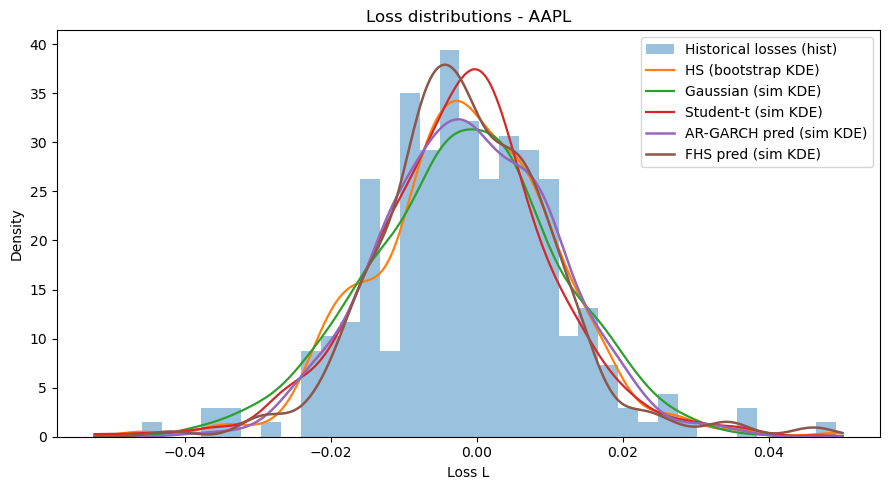

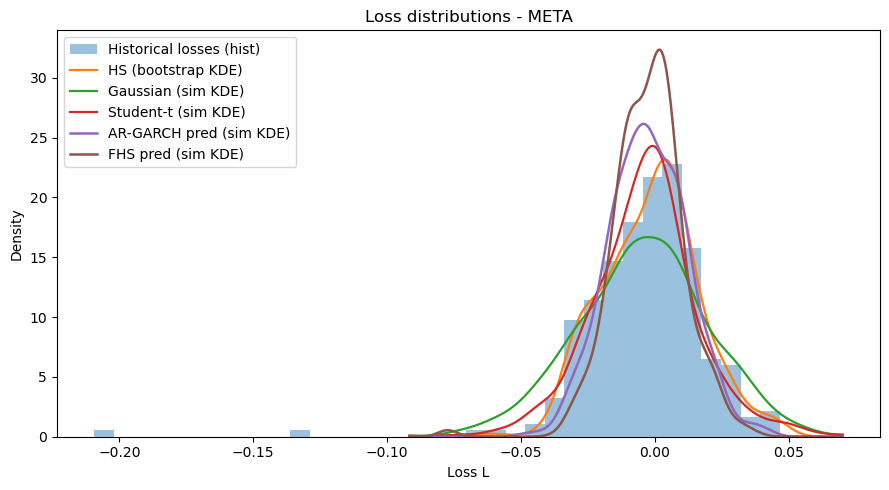

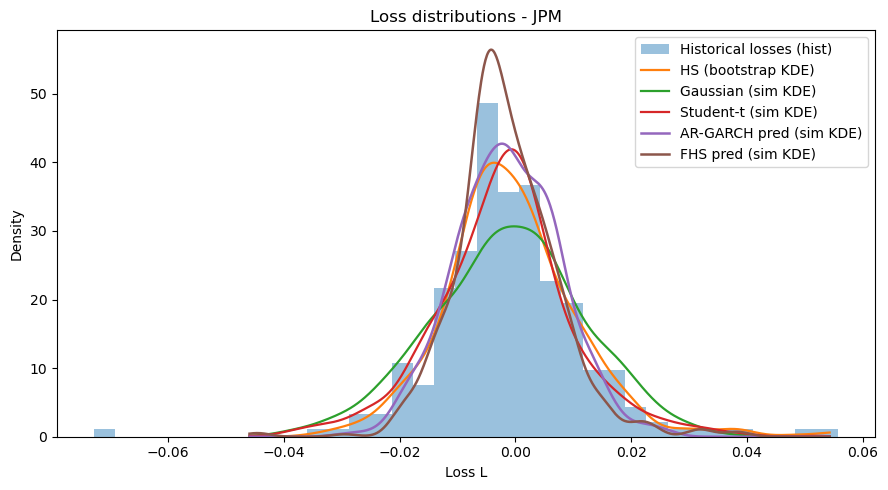

In [21]:
for ticker in TICKERS:
    L_series = (-log_ret[ticker].iloc[:W]).dropna()

    # again, p from AR(p) is always p=0 for us but for generality
    p = int(p_matrix.loc[ticker, 0.95])

    simulate_and_plot_fitted_loss_distributions(
        L_series=L_series,
        r_window=log_ret[ticker].iloc[:W],
        p=p,
        title_suffix=ticker,
        M=1000,
        scale=100.0
    )


### Comparison of results 

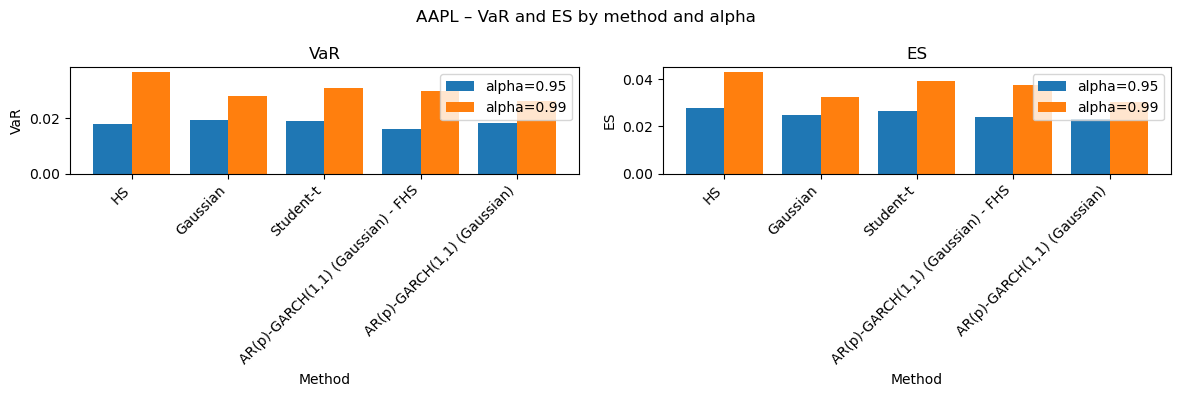

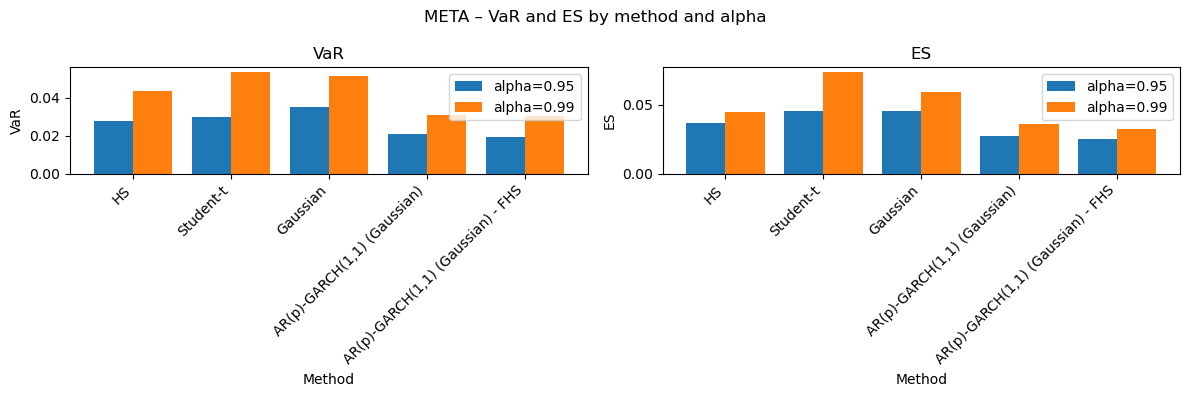

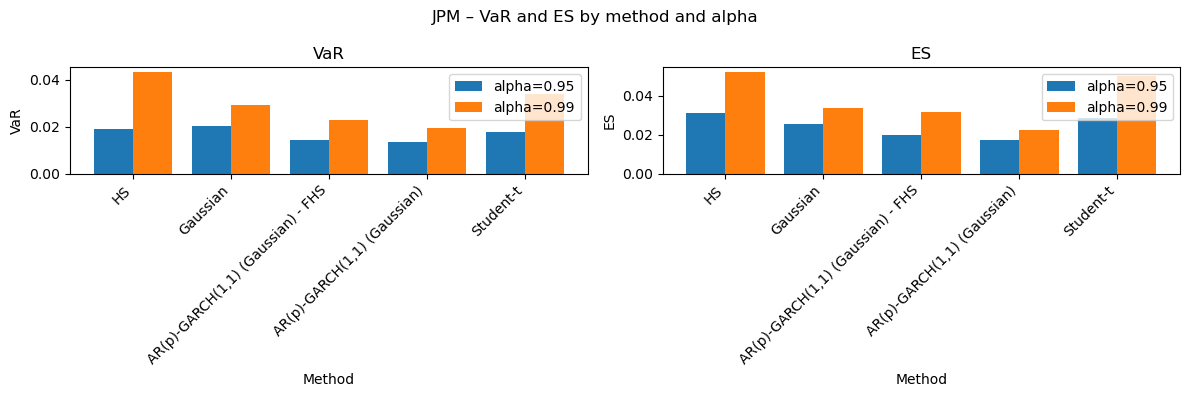

In [22]:
# transforming results into a pd.DataFrame for manipulations
if isinstance(results, list):
    results = pd.DataFrame(results)

results = results[['method', 'ticker', 'alpha', 'VaR', 'ES']]

# sorting for nicer plots
results = results.sort_values(['alpha'])

tickers = results['ticker'].unique()
alphas  = sorted(results['alpha'].unique())

for t in tickers:
    sub = results[results['ticker'] == t].copy()
    methods = sub['method'].unique()
    x = np.arange(len(methods))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    fig.suptitle(f'{t} – VaR and ES by method and alpha')

    metrics = ['VaR', 'ES']

    for ax, metric in zip(axes, metrics):
        # width so that all alpha bars fit nicely in [−0.4, 0.4]
        width = 0.8 / len(alphas)

        for i, a in enumerate(alphas):
            data_a = sub[sub['alpha'] == a].set_index('method').reindex(methods)
            heights = data_a[metric].values

            # shifting each alpha group to the left/right
            ax.bar(x + (i - (len(alphas)-1)/2) * width, heights,
                   width=width, label=f'alpha={a}')

        ax.set_title(metric)
        ax.set_xlabel('Method')
        ax.set_ylabel(metric)
        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=45, ha='right')
        ax.legend()

    plt.tight_layout()
    plt.show()


## 3) Rolling-window backtesting of VaR and ES

Use a rolling window of size W to produce 1-step-ahead VaR/ES at 95% and 99% for each method in Exercise 2. Then, implement the following statistical tests:

- VaR backtests: Kupiec POF and Christoffersen independence tests.
- ES backtest: Acerbi–Székely Z1 test.

## 3.0) Elementary functions for part 3)

In [24]:
def build_rolling_forecasts(log_ret, TICKERS, conf_level, W, p_matrix,
                            scale=100.0, M_fhs=20000, seed_fhs=42,
                            quantile_method="weibull",
                            store_params=True):
    """
    Build rolling 1-step ahead VaR/ES forecasts (on LOSSES) for multiple methods.

    Output DataFrame columns:
      - date: date of the realized point (t+1)
      - asset
      - alpha
      - method  in {"HS","Gaussian","Student-t","AR-GARCH","FHS"}
      - VaR, ES   (on losses)
      - L_real    realized loss at that date
      - R_real    realized return at that date (=-L_real)
      - breach    1 if L_real > VaR else 0
      - params    dict (model informations for Z1 backtest) or None if store_params=False (no need for kupiec/Christoffersen)
    """
    rows = []

    for ticker in TICKERS:
        r = log_ret[ticker].dropna()
        n = len(r)
        if n <= W:
            raise ValueError(f"Not enough data for {ticker}: need > W={W}, got {n}.")

        # end = index position of the last point in the estimation window (t)
        # forecast is for the next point (t+1) => realized at index end+1
        for end in range(W - 1, n - 1):
            r_window = r.iloc[end - W + 1 : end + 1]
            L_window = -r_window

            date = r.index[end + 1]
            R_real = float(r.iloc[end + 1])
            L_real = float(-R_real)

            for alpha in conf_level:

                # --------------------
                # HS
                # --------------------
                var_hs, es_hs, params_hs = forecast_hs(L_window, alpha, quantile_method=quantile_method)
                rows.append({
                    "date": date, "asset": ticker, "alpha": float(alpha),
                    "method": "HS",
                    "VaR": float(var_hs), "ES": float(es_hs),
                    "L_real": L_real, "R_real": R_real,
                    "breach": int(L_real > var_hs),
                    "params": params_hs if store_params else None
                })

                # --------------------
                # Gaussian
                # --------------------
                var_g, es_g, params_g = forecast_gaussian(L_window, alpha)
                rows.append({
                    "date": date, "asset": ticker, "alpha": float(alpha),
                    "method": "Gaussian",
                    "VaR": float(var_g), "ES": float(es_g),
                    "L_real": L_real, "R_real": R_real,
                    "breach": int(L_real > var_g),
                    "params": params_g if store_params else None
                })

                # --------------------
                # Student-t
                # --------------------
                var_t, es_t, params_t = forecast_student_t(L_window, alpha)
                rows.append({
                    "date": date, "asset": ticker, "alpha": float(alpha),
                    "method": "Student-t",
                    "VaR": float(var_t), "ES": float(es_t),
                    "L_real": L_real, "R_real": R_real,
                    "breach": int(L_real > var_t),
                    "params": params_t if store_params else None
                })

                # --------------------
                # AR(p)-GARCH(1,1) Gaussian, and (2.e) FHS
                # --------------------
                p = int(p_matrix.loc[ticker, alpha])

                # Fit once, reuse for AR-GARCH and FHS
                res = fit_ar_garch_gaussian(r_window, p=p, scale=scale, disp="off")
                mu_next, sigma_next = garch_one_step_mu_sigma(res, scale=scale)

                # AR-GARCH Gaussian (on LOSSES)
                var_ag, es_ag, params_ag = forecast_ar_garch_gaussian_from_mu_sigma(mu_next, sigma_next, alpha)
                rows.append({
                    "date": date, "asset": ticker, "alpha": float(alpha),
                    "method": "AR-GARCH",
                    "VaR": float(var_ag), "ES": float(es_ag),
                    "L_real": L_real, "R_real": R_real,
                    "breach": int(L_real > var_ag),
                    "params": params_ag if store_params else None
                })

                # FHS (we use a rolling seed so it doesn't reuse the same bootstrap pattern for every day)
                var_f, es_f, params_f = forecast_fhs_from_res(
                    res, alpha,
                    M=M_fhs,
                    random_state=int(seed_fhs + end),   # day-dependent seed
                    scale=scale,
                    quantile_method=quantile_method
                )
                rows.append({
                    "date": date, "asset": ticker, "alpha": float(alpha),
                    "method": "FHS",
                    "VaR": float(var_f), "ES": float(es_f),
                    "L_real": L_real, "R_real": R_real,
                    "breach": int(L_real > var_f),
                    "params": params_f if store_params else None
                })

    df_forecasts = pd.DataFrame(rows)
    df_forecasts.sort_values(["alpha", "date"], inplace=True)
    df_forecasts.reset_index(drop=True, inplace=True)
    return df_forecasts


In [25]:
# ----------------------------
# Helpers
# ----------------------------

def breaches_from_var(L_real, VaR):
    """
    Return array of 0/1 breaches: I_t = 1{L_real_t > VaR_t}.
    Inputs can be list/np.array/pd.Series.
    """
    L = np.asarray(L_real, dtype=float)
    V = np.asarray(VaR, dtype=float)
    if L.shape != V.shape:
        raise ValueError("L_real and VaR must have the same shape.")
    return (L > V).astype(int)


def _loglik_bernoulli(n1, n0, p, eps=1e-12):
    """
    Log-likelihood for Bernoulli with p, with safe logs.
    """
    p = float(np.clip(p, eps, 1.0 - eps))
    return n1 * np.log(p) + n0 * np.log(1.0 - p)


# ============================================================
# Kupiec POF test (Unconditional coverage)
# ============================================================

def kupiec_pof_test(breaches, alpha, eps=1e-12):
    """
    Kupiec Proportion-Of-Failures test (unconditional coverage).

    H0: P(breach) = 1 - alpha
    Input:
      breaches: array-like of 0/1
      alpha: confidence level for VaR (0.95 or 0.99)
    Output: dict with LR stat, p-value, counts.
    """
    I = np.asarray(breaches, dtype=int)
    T = int(I.size)
    N = int(I.sum())
    p0 = float(1.0 - alpha)

    # MLE under H1
    phat = N / T if T > 0 else np.nan

    # log-likelihood under H0 and H1
    ll0 = _loglik_bernoulli(N, T - N, p0, eps=eps)
    ll1 = _loglik_bernoulli(N, T - N, phat if T > 0 else 0.5, eps=eps)

    LR = float(-2.0 * (ll0 - ll1))
    pval = float(1.0 - chi2.cdf(LR, df=1))

    return {
        "T": T,
        "N": N,
        "alpha": float(alpha),
        "p0": p0,
        "phat": float(phat),
        "LR_pof": LR,
        "pvalue_pof": pval,
    }


# ============================================================
# Christoffersen (Independence & Conditional Coverage)
# ============================================================

def christoffersen_independence_test(breaches, eps=1e-12):
    """
    Christoffersen independence test using 2-state Markov chain on breaches.

    H0: breaches are independent (i.i.d Bernoulli with constant p)
    H1: first-order Markov dependence (p01 != p11)

    Returns dict with LR_ind, p-value, and transition counts.
    """
    I = np.asarray(breaches, dtype=int)
    if I.size < 2:
        raise ValueError("Need at least 2 observations for Christoffersen independence test.")

    # Transition counts n_ij
    I0 = I[:-1]
    I1 = I[1:]
    n00 = int(((I0 == 0) & (I1 == 0)).sum())
    n01 = int(((I0 == 0) & (I1 == 1)).sum())
    n10 = int(((I0 == 1) & (I1 == 0)).sum())
    n11 = int(((I0 == 1) & (I1 == 1)).sum())

    # Under independence (restricted): single p_hat
    T = int(I.size)
    N = int(I.sum())
    phat = N / T if T > 0 else 0.5

    ll0 = _loglik_bernoulli(n01 + n11, n00 + n10, phat, eps=eps)

    # Under Markov (unrestricted): p01 and p11
    denom01 = n00 + n01
    denom11 = n10 + n11
    p01 = n01 / denom01 if denom01 > 0 else 0.0
    p11 = n11 / denom11 if denom11 > 0 else 0.0

    ll1 = 0.0
    if denom01 > 0:
        ll1 += _loglik_bernoulli(n01, n00, p01, eps=eps)
    if denom11 > 0:
        ll1 += _loglik_bernoulli(n11, n10, p11, eps=eps)

    LR = float(-2.0 * (ll0 - ll1))
    pval = float(1.0 - chi2.cdf(LR, df=1))

    return {
        "n00": n00, "n01": n01, "n10": n10, "n11": n11,
        "phat": float(phat),
        "p01": float(p01), "p11": float(p11),
        "LR_ind": LR,
        "pvalue_ind": pval,
    }


def christoffersen_conditional_coverage_test(breaches, alpha, eps=1e-12):
    """
    Christoffersen conditional coverage test:
      LR_cc = LR_pof + LR_ind  ~ chi2(df=2) under H0.

    Returns dict with:
      - Kupiec POF results,
      - Independence results,
      - Joint LR_cc and p-value.
    """
    out_pof = kupiec_pof_test(breaches, alpha, eps=eps)
    out_ind = christoffersen_independence_test(breaches, eps=eps)

    LR_cc = float(out_pof["LR_pof"] + out_ind["LR_ind"])
    pval_cc = float(1.0 - chi2.cdf(LR_cc, df=2))

    return {
        **out_pof,
        **out_ind,
        "LR_cc": LR_cc,
        "pvalue_cc": pval_cc,
    }


# ============================================================
# Acerbi & Szekely Z1 test for ES
# ============================================================

def z1_statistic(L_real, VaR, ES):
    """
    Compute observed Z1 and N (number of VaR breaches):
      I_t = 1{L_t > VaR_t}
      Z1 = (1/N) sum_t (L_t/ES_t - 1) I_t

    Returns (Z1, N). If N==0 -> (np.nan, 0)
    """
    L = np.asarray(L_real, dtype=float)
    V = np.asarray(VaR, dtype=float)
    E = np.asarray(ES, dtype=float)

    if not (L.shape == V.shape == E.shape):
        raise ValueError("L_real, VaR, ES must have the same shape.")

    I = (L > V)
    N = int(I.sum())
    if N == 0:
        return np.nan, 0

    z = (L[I] / E[I]) - 1.0
    return float(np.mean(z)), N


def acerbi_szekely_z1_test(L_real, VaR, ES, params_list, simulate_one_step, M=1000, seed=123):
    """
    Simulation-based Z1 test (primarily one-sided for underestimation of ES).

    Inputs:
      L_real: array-like realized losses (out-of-sample)
      VaR:    array-like predicted VaR on losses (same length)
      ES:     array-like predicted ES on losses (same length)
      params_list: list-like of params dicts, one per date t (same length)
      simulate_one_step: function(params, size, rng) -> np.ndarray of simulated losses
                         (use your simulate_hs / simulate_gaussian / simulate_student_t / simulate_ar_garch_gaussian / simulate_fhs)
      M: number of simulations (1000 in the project)
      seed: RNG seed

    Output: dict with Z1_obs, pvalue (one-sided), and diagnostics.
    """
    L = np.asarray(L_real, dtype=float)
    V = np.asarray(VaR, dtype=float)
    E = np.asarray(ES, dtype=float)

    if not (L.shape == V.shape == E.shape):
        raise ValueError("L_real, VaR, ES must have the same shape.")
    if len(params_list) != len(L):
        raise ValueError("params_list must have the same length as L_real.")

    # Observed Z1
    Z1_obs, N_obs = z1_statistic(L, V, E)
    if N_obs == 0 or np.isnan(Z1_obs):
        return {
            "Z1_obs": np.nan,
            "N_obs": N_obs,
            "pvalue_one_sided": np.nan,
            "M_effective": 0,
            "note": "No VaR breaches in observed data (N_obs=0): Z1 test inconclusive."
        }

    rng = np.random.default_rng(int(seed))
    Z1_sims = []
    skipped = 0

    for m in range(int(M)):
        # simulate one loss per date (conditionally on that date params)
        L_sim = np.empty_like(L)
        for t in range(len(L)):
            L_sim[t] = float(simulate_one_step(params_list[t], 1, rng)[0])

        Z1_m, N_m = z1_statistic(L_sim, V, E)

        # If the simulated path has zero breaches, Z1 undefined; skip this simulation
        if N_m == 0 or np.isnan(Z1_m):
            skipped += 1
            continue

        Z1_sims.append(Z1_m)

    Z1_sims = np.asarray(Z1_sims, dtype=float)
    M_eff = int(Z1_sims.size)

    if M_eff == 0:
        return {
            "Z1_obs": float(Z1_obs),
            "N_obs": N_obs,
            "pvalue_one_sided": np.nan,
            "M_effective": 0,
            "note": "All simulations had zero breaches (cannot form null distribution)."
        }

    # One-sided p-value: reject for large positive Z1 (ES underestimation)
    pval = float(np.mean(Z1_sims >= Z1_obs))

    return {
        "Z1_obs": float(Z1_obs),
        "N_obs": int(N_obs),
        "pvalue_one_sided": pval,
        "M_requested": int(M),
        "M_effective": M_eff,
        "M_skipped_no_breach": int(skipped),
        "Z1_sim_mean": float(np.mean(Z1_sims)),
        "Z1_sim_std": float(np.std(Z1_sims, ddof=1)) if M_eff > 1 else 0.0,
    }


## 3.a) Kupiec

In [26]:
from scipy.stats import chi2

In [27]:
# Parameters
W = 252
conf_level_bt = [0.95, 0.99] 

# --- Build rolling forecasts (can take time because of GARCH/FHS) ---
df_forecasts = build_rolling_forecasts(
    log_ret=log_ret,
    TICKERS=TICKERS,
    conf_level=conf_level_bt,
    W=W,
    p_matrix=p_matrix,
    scale=100.0,
    M_fhs=20000,
    seed_fhs=42,
    quantile_method="weibull",
    store_params=False      # Kupiec does NOT need params, so let's save some space
)

print(df_forecasts.head())
print("Rows:", len(df_forecasts))
print("Alphas:", sorted(df_forecasts["alpha"].unique()))
print("Methods:", sorted(df_forecasts["method"].unique()))

# Kupiec POF test for each (asset, method, alpha)
methods = ["HS", "Gaussian", "Student-t", "AR-GARCH", "FHS"]

kupiec_results = []

for ticker in TICKERS:
    for alpha_bt in conf_level_bt:
        for method in methods:
            sub = df_forecasts[
                (df_forecasts["asset"] == ticker) &
                (df_forecasts["method"] == method) &
                (df_forecasts["alpha"] == alpha_bt)
            ].sort_values("date")

            breaches = sub["breach"].to_numpy(dtype=int)

            out = kupiec_pof_test(breaches, alpha=alpha_bt)

            kupiec_results.append({
                "alpha": alpha_bt,
                "asset": ticker,
                "method": method,
                "T": out["T"],
                "N": out["N"],
                "expected_N": out["T"] * out["p0"],
                "phat": out["phat"],
                "p0": out["p0"],
                "LR_pof": out["LR_pof"],
                "pvalue_pof": out["pvalue_pof"],
            })

kupiec_df = (
    pd.DataFrame(kupiec_results)
      .sort_values(["alpha"])
      .reset_index(drop=True)
)

kupiec_df


        date asset  alpha     method       VaR        ES    L_real    R_real  \
0 2024-01-05  AAPL   0.95         HS  0.017909  0.027557  0.004021 -0.004021   
1 2024-01-05  AAPL   0.95   Gaussian  0.019421  0.024738  0.004021 -0.004021   
2 2024-01-05  AAPL   0.95  Student-t  0.018856  0.026424  0.004021 -0.004021   
3 2024-01-05  AAPL   0.95   AR-GARCH  0.018229  0.023184  0.004021 -0.004021   
4 2024-01-05  AAPL   0.95        FHS  0.015638  0.025625  0.004021 -0.004021   

   breach params  
0       0   None  
1       0   None  
2       0   None  
3       0   None  
4       0   None  
Rows: 11100
Alphas: [0.95, 0.99]
Methods: ['AR-GARCH', 'FHS', 'Gaussian', 'HS', 'Student-t']


,alpha,asset,method,T,N,expected_N,phat,p0,LR_pof,pvalue_pof
0,0.95,AAPL,HS,370,33,18.5,0.089189,0.05,9.803180,0.001742
1,0.95,AAPL,Gaussian,370,31,18.5,0.083784,0.05,7.455310,0.006325
2,0.95,AAPL,Student-t,370,40,18.5,0.108108,0.05,20.031440,0.000008
3,0.95,AAPL,AR-GARCH,370,31,18.5,0.083784,0.05,7.455310,0.006325
4,0.95,AAPL,FHS,370,31,18.5,0.083784,0.05,7.455310,0.006325
5,0.95,META,AR-GARCH,370,16,18.5,0.043243,0.05,0.371915,0.541962
6,0.95,META,HS,370,21,18.5,0.056757,0.05,0.341395,0.559025
7,0.95,META,Gaussian,370,17,18.5,0.045946,0.05,0.131441,0.716943
8,0.95,META,FHS,370,21,18.5,0.056757,0.05,0.341395,0.559025
9,0.95,META,Student-t,370,24,18.5,0.064865,0.05,1.580101,0.208746


In [29]:
# adding the explicit result of the Kupiec test to the dataframe
prim_confid_value = 0.05
kupiec_df["pass_5pct"] = kupiec_df["pvalue_pof"] > prim_confid_value
display(kupiec_df.loc[:, ["alpha","asset","method","pass_5pct"]])
display(kupiec_df.pivot_table(index=["alpha","asset","method"], values="pass_5pct", aggfunc="first", sort=False))
# (macro-interpretation : if (pass_5pct == True) => the model was "good" (w.r.t. this test, the corresponding alpha, and from a statistical pov (prim_confid_value)))

,alpha,asset,method,pass_5pct
0,0.95,AAPL,HS,False
1,0.95,AAPL,Gaussian,False
2,0.95,AAPL,Student-t,False
3,0.95,AAPL,AR-GARCH,False
4,0.95,AAPL,FHS,False
5,0.95,META,AR-GARCH,True
6,0.95,META,HS,True
7,0.95,META,Gaussian,True
8,0.95,META,FHS,True
9,0.95,META,Student-t,True


pass_5pct
alpha asset method              
0.95  AAPL  HS             False
            Gaussian       False
            Student-t      False
            AR-GARCH       False
            FHS            False
      META  AR-GARCH        True
            HS              True
            Gaussian        True
            FHS             True
            Student-t       True
      JPM   Student-t       True
            FHS             True
            HS              True
            Gaussian        True
            AR-GARCH        True
0.99  AAPL  HS              True
      META  HS              True
      AAPL  AR-GARCH       False
            FHS             True
            Student-t       True
            Gaussian       False
      META  FHS             True
            Student-t       True
            AR-GARCH        True
            Gaussian       False
      JPM   HS              True
            Gaussian       False
            Student-t      False
            AR-GARCH       False
            FHS             True

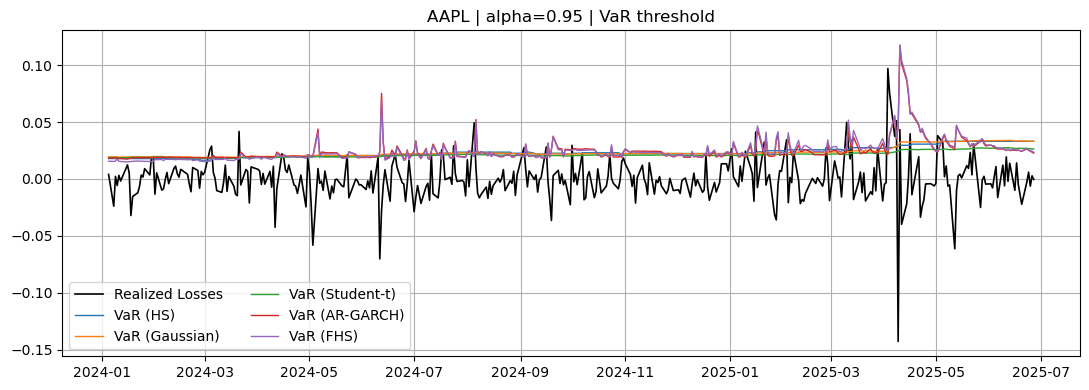

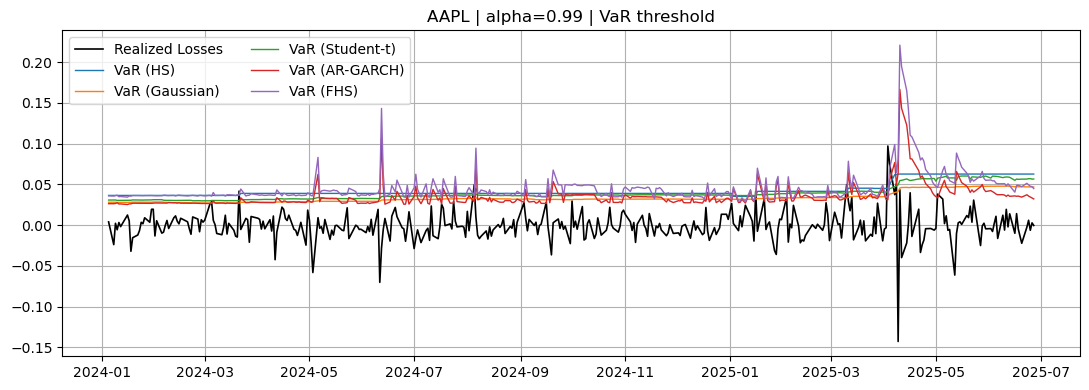

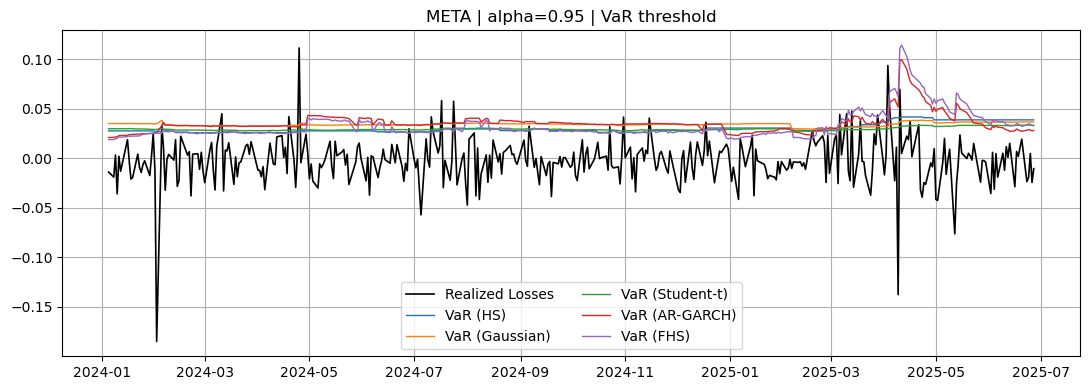

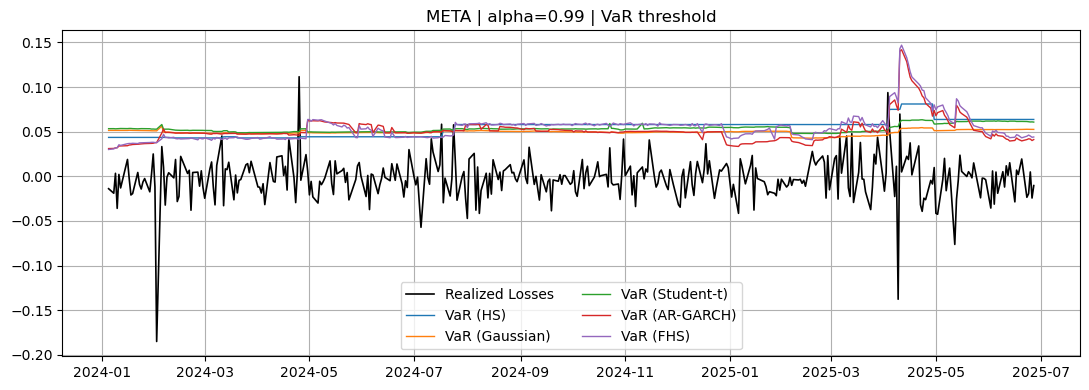

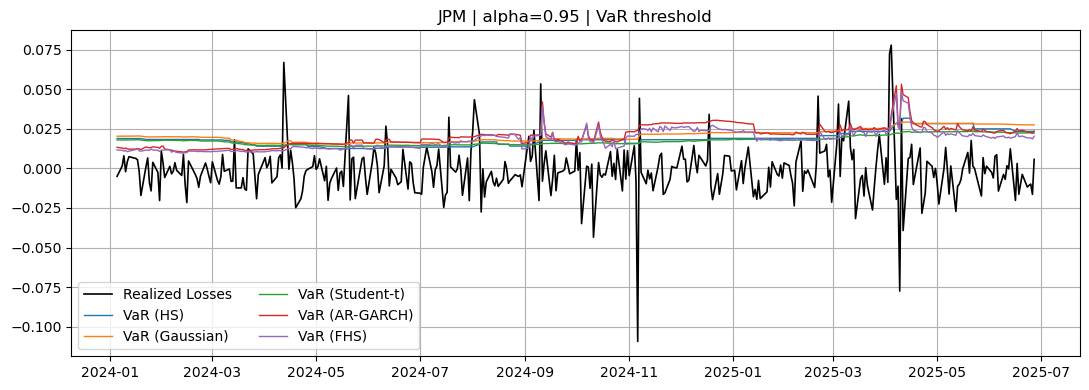

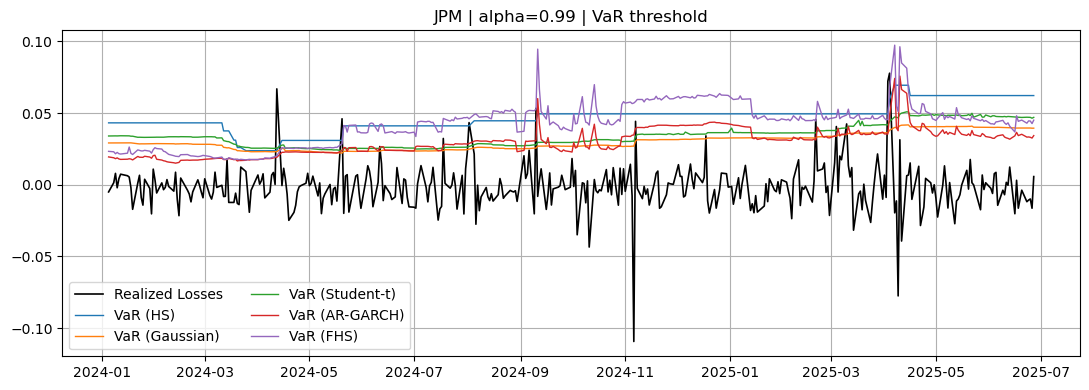

In [30]:
methods = ["HS", "Gaussian", "Student-t", "AR-GARCH", "FHS"]
conf_level_bt = [0.95, 0.99]

for ticker in TICKERS:
    for alpha_bt in conf_level_bt:
        plt.figure(figsize=(11, 4))
        sub0 = df_forecasts[(df_forecasts["asset"] == ticker) & (df_forecasts["alpha"] == alpha_bt)].sort_values("date")

        if len(sub0) == 0:
            continue

        plt.plot(sub0["date"], -sub0["R_real"], color="black", label="Realized Losses", linewidth=1.2)

        for method in methods:
            sub = sub0[sub0["method"] == method]
            if len(sub) == 0:
                continue
            plt.plot(sub["date"], sub["VaR"], label=f"VaR ({method})", linewidth=1.0)

        plt.title(f"{ticker} | alpha={alpha_bt} | VaR threshold")
        plt.legend(ncol=2)
        plt.tight_layout()
        plt.grid(True)
        plt.show()

## 3.a) Christoffersen

In [31]:
conf_level_bt = [0.95, 0.99]
methods = ["HS", "Gaussian", "Student-t", "AR-GARCH", "FHS"]

christ_results = []

for ticker in TICKERS:
    for alpha_bt in conf_level_bt:
        for method in methods:
            sub = df_forecasts[
                (df_forecasts["asset"] == ticker) &
                (df_forecasts["method"] == method) &
                (df_forecasts["alpha"] == alpha_bt)
            ].sort_values("date")

            breaches = sub["breach"].to_numpy(dtype=int)

            out = christoffersen_conditional_coverage_test(breaches, alpha=alpha_bt)

            christ_results.append({
                "alpha": alpha_bt,
                "asset": ticker,
                "method": method,
                "T": out["T"],
                "N": out["N"],

                # Unconditional coverage (Kupiec)
                "LR_pof": out["LR_pof"],
                "pvalue_pof": out["pvalue_pof"],

                # Independence
                "n00": out["n00"], "n01": out["n01"], "n10": out["n10"], "n11": out["n11"],
                "p01": out["p01"], "p11": out["p11"],
                "LR_ind": out["LR_ind"],
                "pvalue_ind": out["pvalue_ind"],

                # Joint conditional coverage
                "LR_cc": out["LR_cc"],
                "pvalue_cc": out["pvalue_cc"],
            })

christ_df = (
    pd.DataFrame(christ_results)
      .sort_values(["alpha"])
      .reset_index(drop=True)
)

christ_df


,alpha,asset,method,T,N,LR_pof,pvalue_pof,n00,n01,n10,n11,p01,p11,LR_ind,pvalue_ind,LR_cc,pvalue_cc
0,0.95,AAPL,HS,370,33,9.803180,0.001742,309,27,27,6,0.080357,0.181818,3.088196,0.078862,12.891376,0.001587
1,0.95,AAPL,Gaussian,370,31,7.455310,0.006325,312,26,26,5,0.076923,0.161290,2.166115,0.141082,9.621425,0.008142
2,0.95,AAPL,Student-t,370,40,20.031440,0.000008,297,32,32,8,0.097264,0.200000,3.297690,0.069377,23.329130,0.000009
3,0.95,AAPL,AR-GARCH,370,31,7.455310,0.006325,310,28,28,3,0.082840,0.096774,0.069110,0.792637,7.524420,0.023232
4,0.95,AAPL,FHS,370,31,7.455310,0.006325,310,28,28,3,0.082840,0.096774,0.069110,0.792637,7.524420,0.023232
5,0.95,META,AR-GARCH,370,16,0.371915,0.541962,337,16,16,0,0.045326,0.000000,1.451044,0.228360,1.822959,0.401929
6,0.95,META,HS,370,21,0.341395,0.559025,328,20,20,1,0.057471,0.047619,0.037859,0.845727,0.379253,0.827268
7,0.95,META,Gaussian,370,17,0.131441,0.716943,336,16,16,1,0.045455,0.058824,0.061229,0.804564,0.192670,0.908160
8,0.95,META,FHS,370,21,0.341395,0.559025,328,20,20,1,0.057471,0.047619,0.037859,0.845727,0.379253,0.827268
9,0.95,META,Student-t,370,24,1.580101,0.208746,322,23,23,1,0.066667,0.041667,0.260311,0.609907,1.840412,0.398437


In [32]:
# adding the explicit result of the Christoffersen tests to the dataframe
# pass/fail at 5% level again
christ_df["pass_cc_5pct"]  = christ_df["pvalue_cc"]  > prim_confid_value
christ_df["pass_pof_5pct"] = christ_df["pvalue_pof"] > prim_confid_value
christ_df["pass_ind_5pct"] = christ_df["pvalue_ind"] > prim_confid_value


In [33]:
christ_df

,alpha,asset,method,T,N,LR_pof,pvalue_pof,n00,n01,n10,n11,p01,p11,LR_ind,pvalue_ind,LR_cc,pvalue_cc,pass_cc_5pct,pass_pof_5pct,pass_ind_5pct
0,0.95,AAPL,HS,370,33,9.803180,0.001742,309,27,27,6,0.080357,0.181818,3.088196,0.078862,12.891376,0.001587,False,False,True
1,0.95,AAPL,Gaussian,370,31,7.455310,0.006325,312,26,26,5,0.076923,0.161290,2.166115,0.141082,9.621425,0.008142,False,False,True
2,0.95,AAPL,Student-t,370,40,20.031440,0.000008,297,32,32,8,0.097264,0.200000,3.297690,0.069377,23.329130,0.000009,False,False,True
3,0.95,AAPL,AR-GARCH,370,31,7.455310,0.006325,310,28,28,3,0.082840,0.096774,0.069110,0.792637,7.524420,0.023232,False,False,True
4,0.95,AAPL,FHS,370,31,7.455310,0.006325,310,28,28,3,0.082840,0.096774,0.069110,0.792637,7.524420,0.023232,False,False,True
5,0.95,META,AR-GARCH,370,16,0.371915,0.541962,337,16,16,0,0.045326,0.000000,1.451044,0.228360,1.822959,0.401929,True,True,True
6,0.95,META,HS,370,21,0.341395,0.559025,328,20,20,1,0.057471,0.047619,0.037859,0.845727,0.379253,0.827268,True,True,True
7,0.95,META,Gaussian,370,17,0.131441,0.716943,336,16,16,1,0.045455,0.058824,0.061229,0.804564,0.192670,0.908160,True,True,True
8,0.95,META,FHS,370,21,0.341395,0.559025,328,20,20,1,0.057471,0.047619,0.037859,0.845727,0.379253,0.827268,True,True,True
9,0.95,META,Student-t,370,24,1.580101,0.208746,322,23,23,1,0.066667,0.041667,0.260311,0.609907,1.840412,0.398437,True,True,True


In [34]:
display(christ_df.loc[:, ["alpha","asset","method","pass_cc_5pct"]])
display(christ_df.pivot_table(index=["alpha","asset","method"], values="pass_cc_5pct", aggfunc="first", sort=False))

,alpha,asset,method,pass_cc_5pct
0,0.95,AAPL,HS,False
1,0.95,AAPL,Gaussian,False
2,0.95,AAPL,Student-t,False
3,0.95,AAPL,AR-GARCH,False
4,0.95,AAPL,FHS,False
5,0.95,META,AR-GARCH,True
6,0.95,META,HS,True
7,0.95,META,Gaussian,True
8,0.95,META,FHS,True
9,0.95,META,Student-t,True


pass_cc_5pct
alpha asset method                 
0.95  AAPL  HS                False
            Gaussian          False
            Student-t         False
            AR-GARCH          False
            FHS               False
      META  AR-GARCH           True
            HS                 True
            Gaussian           True
            FHS                True
            Student-t          True
      JPM   Student-t          True
            FHS                True
            HS                 True
            Gaussian           True
            AR-GARCH           True
0.99  AAPL  HS                 True
      META  HS                 True
      AAPL  AR-GARCH          False
            FHS                True
            Student-t          True
            Gaussian          False
      META  FHS                True
            Student-t          True
            AR-GARCH           True
            Gaussian          False
      JPM   HS                 True
            Gaussian          False
            Student-t         False
            AR-GARCH          False
            FHS                True

## 3.a) Z1

In [35]:
# ES backtest (Acerbi–Szekely Z1), alpha in {0.95, 0.99}
W = 252
conf_level_bt = [0.95, 0.99]

# IMPORTANT: Z1 needs params => store_params=True
df_forecasts_z1 = build_rolling_forecasts(
    log_ret=log_ret,
    TICKERS=TICKERS,
    conf_level=conf_level_bt,
    W=W,
    p_matrix=p_matrix,
    scale=100.0,
    M_fhs=20000,
    seed_fhs=42,
    quantile_method="weibull",
    store_params=True
)

methods = ["HS", "Gaussian", "Student-t", "AR-GARCH", "FHS"]
M = 1000
seed = 123

z1_results = []

for ticker in TICKERS:
    for alpha_bt in conf_level_bt:
        for method in methods:
            sub = df_forecasts_z1[
                (df_forecasts_z1["asset"] == ticker) &
                (df_forecasts_z1["method"] == method) &
                (df_forecasts_z1["alpha"] == alpha_bt)
            ].sort_values("date")

            L_real = sub["L_real"].to_numpy(dtype=float)
            VaR    = sub["VaR"].to_numpy(dtype=float)
            ES     = sub["ES"].to_numpy(dtype=float)
            params_list = sub["params"].tolist()

            if method == "HS":
                simulate_one_step = simulate_hs
            elif method == "Gaussian":
                simulate_one_step = simulate_gaussian
            elif method == "Student-t":
                simulate_one_step = simulate_student_t
            elif method == "AR-GARCH":
                simulate_one_step = simulate_ar_garch_gaussian
            elif method == "FHS":
                simulate_one_step = simulate_fhs
            else:
                raise ValueError("Unknown method: " + str(method))

            out = acerbi_szekely_z1_test(
                L_real=L_real,
                VaR=VaR,
                ES=ES,
                params_list=params_list,
                simulate_one_step=simulate_one_step,
                M=M,
                seed=seed
            )

            z1_results.append({
                "alpha": alpha_bt,
                "asset": ticker,
                "method": method,
                "Z1_obs": out.get("Z1_obs", np.nan),
                "N_obs": out.get("N_obs", 0),
                "pvalue_one_sided": out.get("pvalue_one_sided", np.nan),
                "M_effective": out.get("M_effective", 0),
                "M_skipped_no_breach": out.get("M_skipped_no_breach", 0),
            })

z1_df = (
    pd.DataFrame(z1_results)
      .sort_values(["alpha"])
      .reset_index(drop=True)
)

z1_df

,alpha,asset,method,Z1_obs,N_obs,pvalue_one_sided,M_effective,M_skipped_no_breach
0,0.95,AAPL,HS,0.030913,33,0.319000,1000,0
1,0.95,AAPL,Gaussian,0.193160,31,0.000000,1000,0
2,0.95,AAPL,Student-t,-0.014922,40,0.504000,1000,0
3,0.95,AAPL,AR-GARCH,0.204794,31,0.000000,1000,0
4,0.95,AAPL,FHS,0.072101,31,0.227000,1000,0
5,0.95,META,AR-GARCH,0.207900,16,0.000000,1000,0
6,0.95,META,HS,0.104028,21,0.155000,1000,0
7,0.95,META,Gaussian,0.270184,17,0.000000,1000,0
8,0.95,META,FHS,0.083205,21,0.204000,1000,0
9,0.95,META,Student-t,0.062503,24,0.234000,1000,0


In [36]:
# adding the explicit result of the Z1 test to the dataframe
# pass/fail at 5% level
z1_df["pass_5pct"] = z1_df["pvalue_one_sided"] > prim_confid_value

In [37]:
display(z1_df.loc[:, ["alpha","asset","method","pass_5pct"]])
display(z1_df.pivot_table(index=["alpha","asset","method"], values="pass_5pct", aggfunc="first", sort=False))


,alpha,asset,method,pass_5pct
0,0.95,AAPL,HS,True
1,0.95,AAPL,Gaussian,False
2,0.95,AAPL,Student-t,True
3,0.95,AAPL,AR-GARCH,False
4,0.95,AAPL,FHS,True
5,0.95,META,AR-GARCH,False
6,0.95,META,HS,True
7,0.95,META,Gaussian,False
8,0.95,META,FHS,True
9,0.95,META,Student-t,True


pass_5pct
alpha asset method              
0.95  AAPL  HS              True
            Gaussian       False
            Student-t       True
            AR-GARCH       False
            FHS             True
      META  AR-GARCH       False
            HS              True
            Gaussian       False
            FHS             True
            Student-t       True
      JPM   Student-t      False
            FHS             True
            HS             False
            Gaussian       False
            AR-GARCH       False
0.99  AAPL  HS             False
      META  HS              True
      AAPL  AR-GARCH       False
            FHS             True
            Student-t       True
            Gaussian       False
      META  FHS             True
            Student-t       True
            AR-GARCH       False
            Gaussian       False
      JPM   HS             False
            Gaussian       False
            Student-t       True
            AR-GARCH       False
            FHS             True

## Compact&Visual results of backtests

In [38]:
# merging tables (keeping only what we need)
k = kupiec_df[["alpha", "asset", "method", "pvalue_pof", "pass_5pct"]].rename(
    columns={"pvalue_pof": "p_kupiec", "pass_5pct": "kupiec_pass"}
)

c = christ_df[["alpha", "asset", "method", "pvalue_cc", "pass_cc_5pct"]].rename(
    columns={"pvalue_cc": "p_chris_cc", "pass_cc_5pct": "chris_cc_pass"}
)

z = z1_df[["alpha", "asset", "method", "pvalue_one_sided", "pass_5pct", "N_obs"]].rename(
    columns={"pvalue_one_sided": "p_z1", "pass_5pct": "z1_pass", "N_obs": "N_obs_z1"}
)

summary = (
    k.merge(c, on=["alpha", "asset", "method"], how="outer")
     .merge(z, on=["alpha", "asset", "method"], how="outer")
)

# color cells to display visually
def fmt_cell(p, passed, label="p"):
    if pd.isna(passed):
        return "⚪ (inconcl.)"
    if pd.isna(p):
        return "⚪ (p=NaN)"
    return ("🟢 " if bool(passed) else "🔴 ") + f"({label}={p:.3f})"

summary["Kupiec"] = [fmt_cell(p, b, "p") for p, b in zip(summary["p_kupiec"], summary["kupiec_pass"])]
summary["Chris-CC"] = [fmt_cell(p, b, "p") for p, b in zip(summary["p_chris_cc"], summary["chris_cc_pass"])]
summary["Z1 (one-sided)"] = [fmt_cell(p, b, "p") for p, b in zip(summary["p_z1"], summary["z1_pass"])]

# simple score (count only available tests)
summary["score_total"] = (
    summary["kupiec_pass"].fillna(False).astype(int) +
    summary["chris_cc_pass"].fillna(False).astype(int) +
    summary["z1_pass"].fillna(0).astype(int)
)

summary["tests_counted"] = (
    summary["kupiec_pass"].notna().astype(int) +
    summary["chris_cc_pass"].notna().astype(int) +
    summary["z1_pass"].notna().astype(int)
)

# final compact and visual display table
scorecard = summary[[
    "alpha", "asset", "method",
    "Kupiec", "Chris-CC", "Z1 (one-sided)",
    "score_total", "tests_counted", "N_obs_z1"
]]

scorecard



,alpha,asset,method,Kupiec,Chris-CC,Z1 (one-sided),score_total,tests_counted,N_obs_z1
0,0.95,AAPL,AR-GARCH,🔴 (p=0.006),🔴 (p=0.023),🔴 (p=0.000),0,3,31
1,0.95,AAPL,FHS,🔴 (p=0.006),🔴 (p=0.023),🟢 (p=0.227),1,3,31
2,0.95,AAPL,Gaussian,🔴 (p=0.006),🔴 (p=0.008),🔴 (p=0.000),0,3,31
3,0.95,AAPL,HS,🔴 (p=0.002),🔴 (p=0.002),🟢 (p=0.319),1,3,33
4,0.95,AAPL,Student-t,🔴 (p=0.000),🔴 (p=0.000),🟢 (p=0.504),1,3,40
5,0.95,JPM,AR-GARCH,🟢 (p=0.724),🟢 (p=0.245),🔴 (p=0.000),2,3,20
6,0.95,JPM,FHS,🟢 (p=0.417),🟢 (p=0.084),🟢 (p=0.083),3,3,22
7,0.95,JPM,Gaussian,🟢 (p=0.905),🟢 (p=0.204),🔴 (p=0.000),2,3,19
8,0.95,JPM,HS,🟢 (p=0.417),🟢 (p=0.084),🔴 (p=0.045),2,3,22
9,0.95,JPM,Student-t,🟢 (p=0.300),🟢 (p=0.090),🔴 (p=0.021),2,3,23


In [39]:
display(scorecard.loc[:, ["alpha","asset","method","score_total"]])
display(scorecard.pivot_table(index=["alpha","asset","method"], values="score_total", aggfunc="first", sort=False))

,alpha,asset,method,score_total
0,0.95,AAPL,AR-GARCH,0
1,0.95,AAPL,FHS,1
2,0.95,AAPL,Gaussian,0
3,0.95,AAPL,HS,1
4,0.95,AAPL,Student-t,1
5,0.95,JPM,AR-GARCH,2
6,0.95,JPM,FHS,3
7,0.95,JPM,Gaussian,2
8,0.95,JPM,HS,2
9,0.95,JPM,Student-t,2


score_total
alpha asset method                
0.95  AAPL  AR-GARCH             0
            FHS                  1
            Gaussian             0
            HS                   1
            Student-t            1
      JPM   AR-GARCH             2
            FHS                  3
            Gaussian             2
            HS                   2
            Student-t            2
      META  AR-GARCH             2
            FHS                  3
            Gaussian             2
            HS                   3
            Student-t            3
0.99  AAPL  AR-GARCH             0
            FHS                  3
            Gaussian             0
            HS                   2
            Student-t            3
      JPM   AR-GARCH             0
            FHS                  3
            Gaussian             0
            HS                   2
            Student-t            1
      META  AR-GARCH             2
            FHS                  3
            Gaussian             0
            HS                   3
            Student-t            3

## 4) Copula fitting (first window)

1. Visualize dependence in returns and copula space using pseudo-observations.
2. Fit Gaussian and t copulas; report parameters.
3. Simulate from fitted copulas and map to empirical marginals; compare with original returns.

In [41]:
from scipy.stats import norm, t as student_t
from copulae import GaussianCopula, StudentCopula

In [42]:
# =====================================================
# Pseudo-observations U on a window
# =====================================================

def compute_pseudo_obs(window_ret: pd.DataFrame) -> pd.DataFrame:
    W = len(window_ret)
    U = window_ret.rank(method="average") / (W + 1)
    return U

# =====================================================
# Empirical inverse CDF
# =====================================================

def empirical_inverse_cdf_from_sorted(u: np.ndarray, data_sorted: np.ndarray) -> np.ndarray:
    """
    u: array in (0,1)
    data_sorted: sorted 1D array of returns (length n)
    """
    u = np.asarray(u, dtype=float)
    data_sorted = np.asarray(data_sorted, dtype=float)
    n = len(data_sorted)

    pos = u * (n + 1)
    pos = np.clip(pos, 1, n) - 1

    lower = np.floor(pos).astype(int)
    upper = np.ceil(pos).astype(int)
    w = pos - lower

    return (1 - w) * data_sorted[lower] + w * data_sorted[upper]


def fit_gauss_t_copulas_copulae(U: pd.DataFrame, df_init: float = 10.0):
    d = U.shape[1]
    gauss_cop = GaussianCopula(dim=d)
    gauss_cop.fit(U.values)

    t_cop = StudentCopula(dim=d, df=df_init)
    t_cop.fit(U.values)

    R_gauss = np.asarray(gauss_cop.sigma, dtype=float)
    R_t = np.asarray(t_cop.sigma, dtype=float)
    nu_t = float(t_cop.params.df)

    return gauss_cop, t_cop, R_gauss, R_t, nu_t

# =====================================================
# like before
# =====================================================

def forecast_copula_portfolio(window_ret: pd.DataFrame,
                              alpha: float,
                              copula_kind: str,
                              N: int = 1000,
                              seed: int = 123,
                              quantile_method: str = "weibull"):
    assets = list(window_ret.columns)
    d = len(assets)

    U = compute_pseudo_obs(window_ret)

    gauss_cop, t_cop, R_gauss, R_t, nu_t = fit_gauss_t_copulas_copulae(U)

    copula_kind = copula_kind.lower()
    if copula_kind in ["gaussian", "gauss"]:
        sigma = R_gauss
        df = None
        U_sim = np.asarray(gauss_cop.random(int(N)), dtype=float)
    elif copula_kind in ["student", "t", "student-t", "t-copula"]:
        sigma = R_t
        df = float(nu_t)
        U_sim = np.asarray(t_cop.random(int(N)), dtype=float)
    else:
        raise ValueError("copula_kind must be 'gaussian' or 'student'.")

    eps = 1e-12
    U_sim = np.clip(U_sim, eps, 1.0 - eps)

    # Storring sorted marginals (empirical inverse CDF)
    data_sorted = {}
    for a in assets:
        data_sorted[a] = np.sort(window_ret[a].values.astype(float))

    # Transforming to returns (empirical inverse)
    R_sim = np.zeros((int(N), d), dtype=float)
    for j, a in enumerate(assets):
        R_sim[:, j] = empirical_inverse_cdf_from_sorted(U_sim[:, j], data_sorted[a])

    R_port_sim = R_sim.mean(axis=1)
    L_port_sim = -R_port_sim

    var = float(np.quantile(L_port_sim, alpha, method=quantile_method))
    es = tail_mean_es(L_port_sim, var)

    params = {
        "assets": assets,
        "copula_kind": "gaussian" if df is None else "student",
        "sigma": np.asarray(sigma, dtype=float),
        "df": df,
        "data_sorted": data_sorted
    }
    return float(var), float(es), params

def simulate_copula_portfolio(params: dict, size: int, rng: np.random.Generator):
    assets = params["assets"]
    sigma = np.asarray(params["sigma"], dtype=float)
    df = params.get("df", None)
    data_sorted = params["data_sorted"]

    d = len(assets)
    n = int(size)

    # Cholesky
    try:
        C = np.linalg.cholesky(sigma)
    except np.linalg.LinAlgError:
        C = np.linalg.cholesky(sigma + 1e-10 * np.eye(d))

    Z = rng.standard_normal((n, d)) @ C.T

    eps = 1e-12
    if df is None:
        U = norm.cdf(Z)
    else:
        df = float(df)
        S = rng.chisquare(df, size=n) / df
        T = Z / np.sqrt(S)[:, None]
        U = student_t.cdf(T, df=df)

    U = np.clip(U, eps, 1.0 - eps)

    R = np.zeros((n, d), dtype=float)
    for j, a in enumerate(assets):
        R[:, j] = empirical_inverse_cdf_from_sorted(U[:, j], data_sorted[a])

    R_port = R.mean(axis=1)
    return -R_port


In [43]:
def build_rolling_forecasts_portfolio_copula(log_ret: pd.DataFrame,
                                             assets: list,
                                             W: int,
                                             alphas: list,
                                             copula_kind: str,
                                             N: int = 1000,
                                             seed: int = 123,
                                             quantile_method: str = "weibull",
                                             store_params: bool = True):
    """
    Rolling 1-step ahead VaR/ES forecasts for an equal-weighted portfolio
    using Gaussian or Student-t copula fit on component returns.

    Returns a DataFrame with one row per (date, alpha), aligned with your Q3 format.
    """
    ret_mat = log_ret[assets].dropna(how="any")  # aligned component returns
    n = len(ret_mat)
    if n <= W:
        raise ValueError(f"Not enough aligned data: need > W={W}, got {n}.")

    method_name = "Copula-Gaussian" if copula_kind.lower() in ["gaussian", "gauss"] else "Copula-Student"
    rows = []

    # end is "t" index position, we forecast for end+1
    for end in range(W - 1, n - 1):
        window_ret = ret_mat.iloc[end - W + 1: end + 1]  # W x 3, dates up to t
        next_date = ret_mat.index[end + 1]               # date of t+1

        # realized portfolio return at t+1 (equal weights)
        R_real = float(ret_mat.iloc[end + 1].mean())
        L_real = float(-R_real)

        for alpha in alphas:
            var, es, params = forecast_copula_portfolio(
                window_ret=window_ret,
                alpha=float(alpha),
                copula_kind=copula_kind,
                N=int(N),
                seed=int(seed + end),               # like for unique asset data analysis : deterministic across windows
                quantile_method=quantile_method
            )

            rows.append({
                "date": next_date,
                "asset": "PORT",
                "method": method_name,
                "alpha": float(alpha),
                "VaR": float(var),
                "ES": float(es),
                "R_real": R_real,
                "L_real": L_real,
                "breach": int(L_real > var),
                "params": params if store_params else None
            })

    df = pd.DataFrame(rows).sort_values(["alpha", "date"]).reset_index(drop=True)
    return df


## 4.a)

Summary of pseudo-observations U:


,AAPL,META,JPM
count,252.000000,252.000000,252.000000
mean,0.500000,0.500000,0.500000
std,0.288104,0.288104,0.288104
min,0.003953,0.003953,0.003953
25%,0.251976,0.251976,0.251976
50%,0.500000,0.500000,0.500000
75%,0.748024,0.748024,0.748024
max,0.996047,0.996047,0.996047


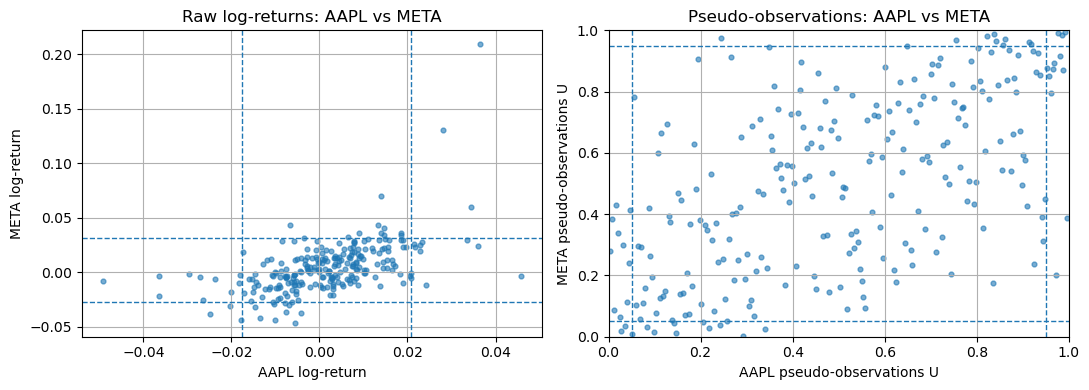

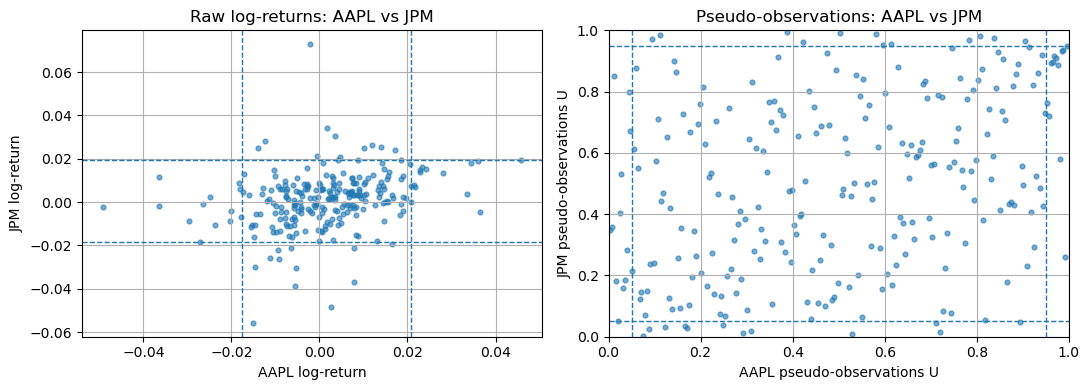

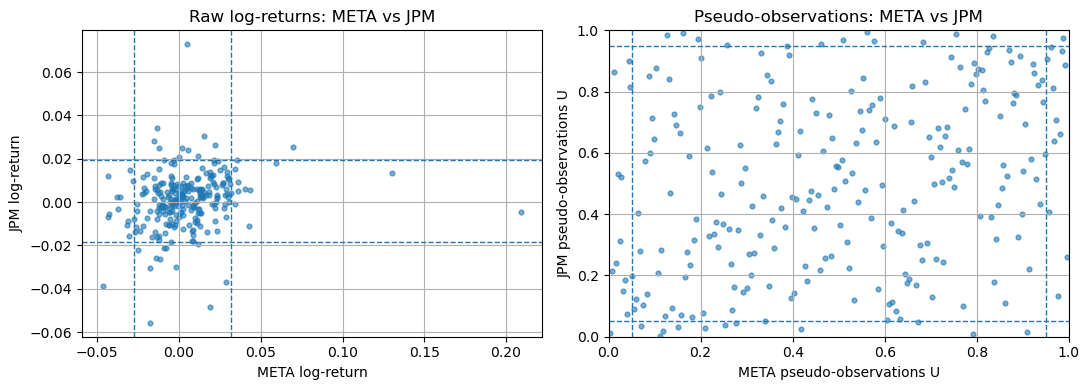

In [44]:
import itertools

# ============================================
# Settings and data selection
# ============================================

W = 252
assets = ["AAPL", "META", "JPM"]

R_window = log_ret[assets].dropna(how="any").iloc[:W]   # (W, 3)

# ============================================
# Pseudo-observations U
# ============================================

U = R_window.rank(method="average") / (W + 1)

print("Summary of pseudo-observations U:")
display(U.describe())

# quantile thresholds for visual tail diagnostics
q_low, q_high = 0.05, 0.95

# ============================================
# Scatter plots (R vs U) for each pair
# ============================================

for i, j in itertools.combinations(assets, 2):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
    # Left : raw returns space
    axes[0].scatter(R_window[i], R_window[j], s=12, alpha=0.6)
    axes[0].set_xlabel(f"{i} log-return")
    axes[0].set_ylabel(f"{j} log-return")
    axes[0].set_title(f"Raw log-returns: {i} vs {j}")
    axes[0].grid(True)

    # showing 5%/95% lines in return space (to separate tails)
    xi_low, xi_high = R_window[i].quantile(q_low), R_window[i].quantile(q_high)
    xj_low, xj_high = R_window[j].quantile(q_low), R_window[j].quantile(q_high)
    axes[0].axvline(xi_low, linestyle="--", linewidth=1)
    axes[0].axvline(xi_high, linestyle="--", linewidth=1)
    axes[0].axhline(xj_low, linestyle="--", linewidth=1)
    axes[0].axhline(xj_high, linestyle="--", linewidth=1)
    
    # Right: pseudo-observations space
    axes[1].scatter(U[i], U[j], s=12, alpha=0.6)
    axes[1].set_xlabel(f"{i} pseudo-observations U")
    axes[1].set_ylabel(f"{j} pseudo-observations U")
    axes[1].set_title(f"Pseudo-observations: {i} vs {j}")
    axes[1].grid(True)

    # showing tail regions again (in U-space)
    axes[1].axvline(q_low, linestyle="--", linewidth=1)
    axes[1].axvline(q_high, linestyle="--", linewidth=1)
    axes[1].axhline(q_low, linestyle="--", linewidth=1)
    axes[1].axhline(q_high, linestyle="--", linewidth=1)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()


## 4.b)

/Users/timo/anaconda3/lib/python3.11/site-packages/scipy/optimize/_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Gaussian copula sigma (correlation matrix):
          AAPL      META       JPM
AAPL  1.000000  0.597894  0.342794
META  0.597894  1.000000  0.286974
JPM   0.342794  0.286974  1.000000

Student-t copula sigma (correlation matrix):
          AAPL      META       JPM
AAPL  1.000000  0.599543  0.349353
META  0.599543  1.000000  0.302104
JPM   0.349353  0.302104  1.000000

Student-t copula df (nu): 13.0554


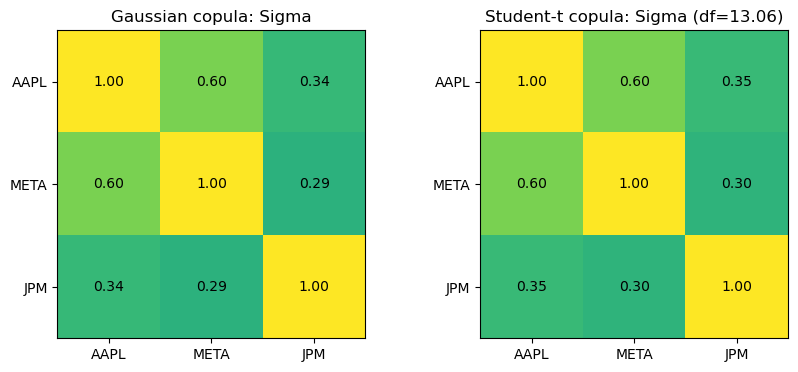

In [45]:
# --------------------------------------------
# Fitting copulas on the single estimation window
# --------------------------------------------
W = 252
assets = ["AAPL", "META", "JPM"]

R_window = log_ret[assets].dropna(how="any").iloc[:W]
U = compute_pseudo_obs(R_window)

gauss_cop, t_cop, R_gauss, R_t, nu_t = fit_gauss_t_copulas_copulae(U)

print("Gaussian copula sigma (correlation matrix):")
print(pd.DataFrame(R_gauss, index=assets, columns=assets))
print("\nStudent-t copula sigma (correlation matrix):")
print(pd.DataFrame(R_t, index=assets, columns=assets))
print(f"\nStudent-t copula df (nu): {nu_t:.4f}")

print("\nGaussian log-likelihood:", gauss_cop.log_lik(U.values))
print("Student-t log-likelihood:", t_cop.log_lik(U.values))

# --------------------------------------------
# Plotting the parameter matrices (heatmaps)
# --------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(R_gauss, vmin=-1, vmax=1)
axes[0].set_title("Gaussian copula: Sigma")
axes[0].set_xticks(range(len(assets)))
axes[0].set_yticks(range(len(assets)))
axes[0].set_xticklabels(assets)
axes[0].set_yticklabels(assets)

# annotatting values
for i in range(len(assets)):
    for j in range(len(assets)):
        axes[0].text(j, i, f"{R_gauss[i, j]:.2f}", ha="center", va="center")

im1 = axes[1].imshow(R_t, vmin=-1, vmax=1)
axes[1].set_title(f"Student-t copula: Sigma (df={nu_t:.2f})")
axes[1].set_xticks(range(len(assets)))
axes[1].set_yticks(range(len(assets)))
axes[1].set_xticklabels(assets)
axes[1].set_yticklabels(assets)

# annotatting values
for i in range(len(assets)):
    for j in range(len(assets)):
        axes[1].text(j, i, f"{R_t[i, j]:.2f}", ha="center", va="center")


## 4.c)

In [46]:
def simulate_assets_from_fitted_copula_single_window(log_ret: pd.DataFrame,
                                                     assets: list,
                                                     W: int,
                                                     copula_kind: str,
                                                     T: int,
                                                     seed: int = 123):
    """
    Fit the copula on the first window of length W (as in Q4),
    then simulate T synthetic returns for the d assets.

    Returns:
      R_sim_df: DataFrame (T x d) of simulated returns
      R_port_sim: pd.Series (T,) equal-weight portfolio returns (optional but handy)
      fitted_params: dict with sigma/df used (for reporting)
    """
    # estimation window
    R_window = log_ret[assets].dropna(how="any").iloc[:W]
    U = compute_pseudo_obs(R_window)

    # fitting copulas
    gauss_cop, t_cop, R_gauss, R_t, nu_t = fit_gauss_t_copulas_copulae(U)

    copula_kind = copula_kind.lower()
    rng = np.random.default_rng(int(seed))

    if copula_kind in ["gaussian", "gauss"]:
        U_sim = np.asarray(gauss_cop.random(int(T)), dtype=float)
        sigma = np.asarray(R_gauss, dtype=float)
        df = None
    elif copula_kind in ["student", "t", "student-t", "t-copula"]:
        U_sim = np.asarray(t_cop.random(int(T)), dtype=float)
        sigma = np.asarray(R_t, dtype=float)
        df = float(nu_t)
    else:
        raise ValueError("copula_kind must be 'gaussian' or 'student'.")

    # (avoid exact 0/1) ***
    eps = 1e-12
    U_sim = np.clip(U_sim, eps, 1.0 - eps)

    # inverse ECDF from window (sorted marginals)
    data_sorted = {a: np.sort(R_window[a].values.astype(float)) for a in assets}

    # transforming Us to returns ---
    R_sim = np.zeros((int(T), len(assets)), dtype=float)
    for j, a in enumerate(assets):
        R_sim[:, j] = empirical_inverse_cdf_from_sorted(U_sim[:, j], data_sorted[a])

    R_sim_df = pd.DataFrame(R_sim, columns=assets)
    R_port_sim = R_sim_df.mean(axis=1)   # equal-weight portfolio return (<=> 1/3 each)

    fitted_params = {"sigma": sigma, "df": df, "nu_t": df}

    return R_sim_df, R_port_sim, fitted_params


T_total = 622


/Users/timo/anaconda3/lib/python3.11/site-packages/scipy/optimize/_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/Users/timo/anaconda3/lib/python3.11/site-packages/scipy/optimize/_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Gaussian copula fitted sigma:
           AAPL      META       JPM
AAPL  1.000000  0.597894  0.342794
META  0.597894  1.000000  0.286974
JPM   0.342794  0.286974  1.000000

Student-t copula fitted sigma:
           AAPL      META       JPM
AAPL  1.000000  0.599543  0.349353
META  0.599543  1.000000  0.302104
JPM   0.349353  0.302104  1.000000

Student-t df: 13.055426028003982


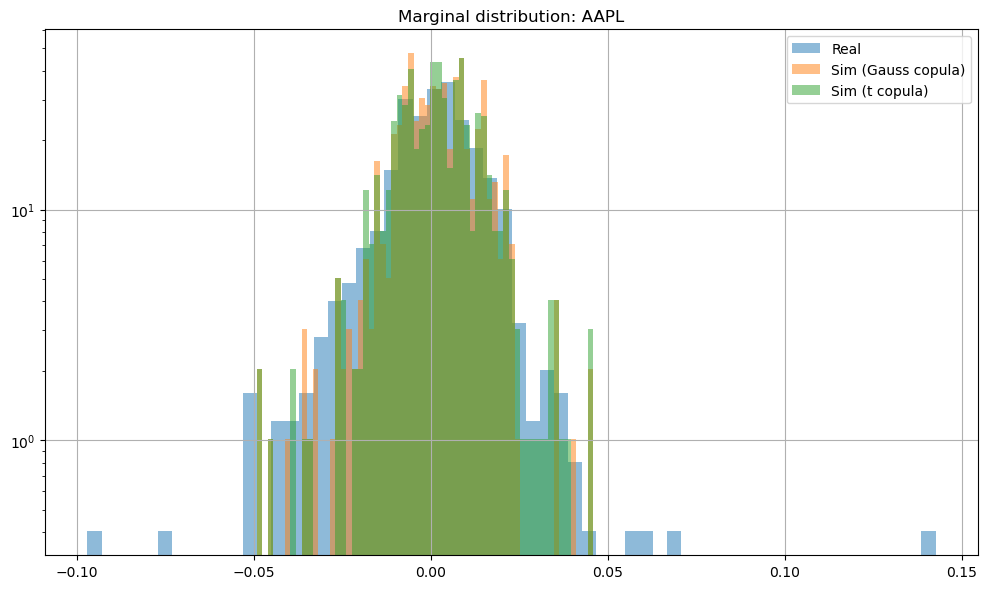

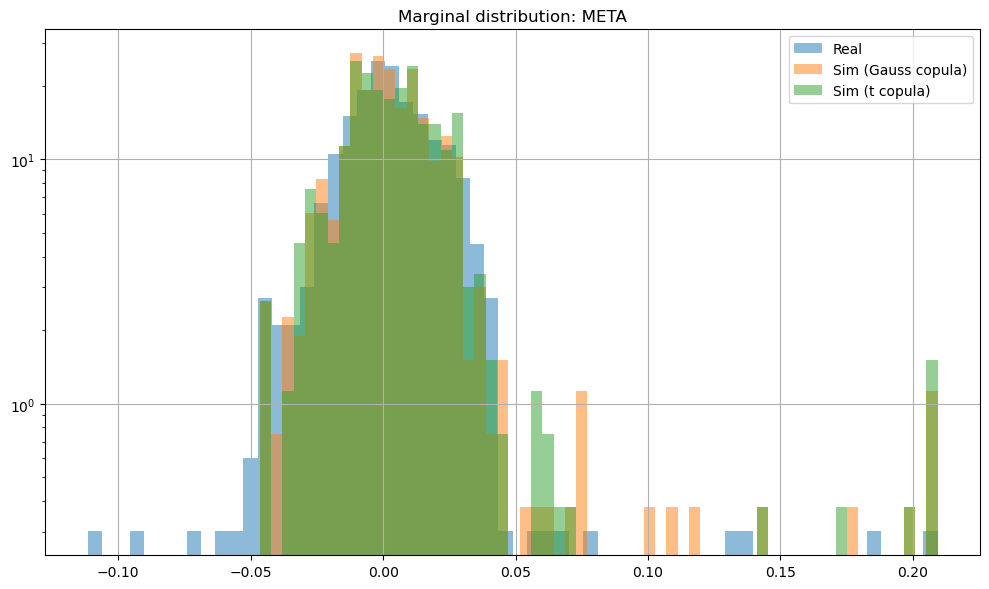

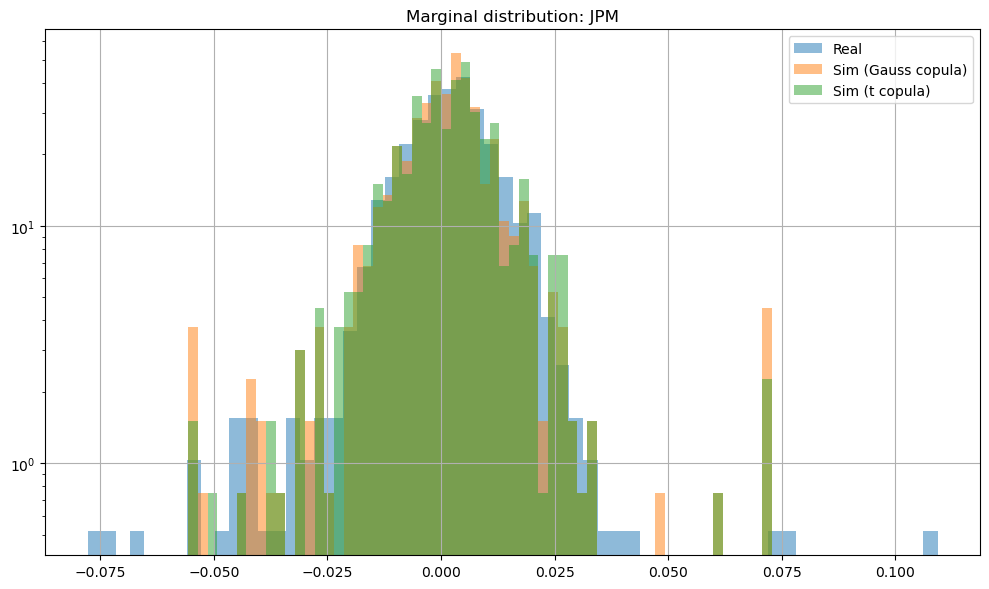

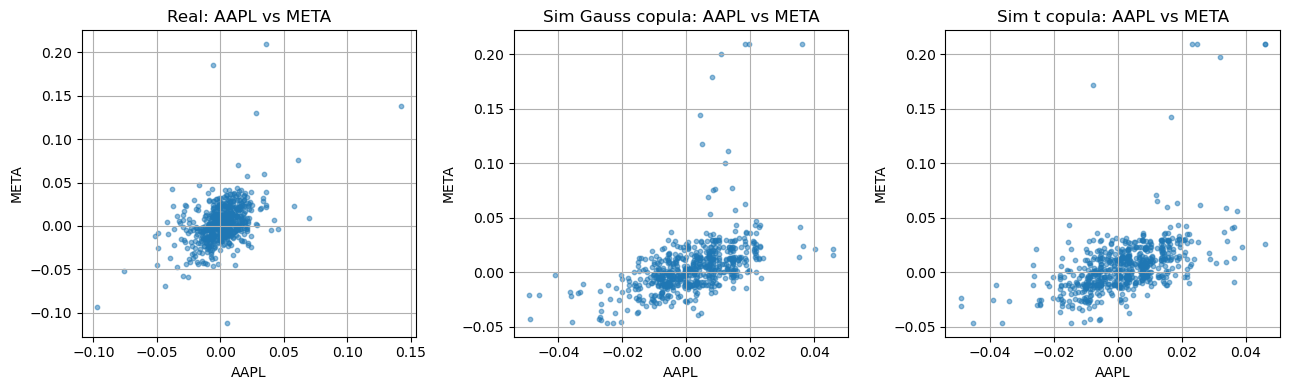

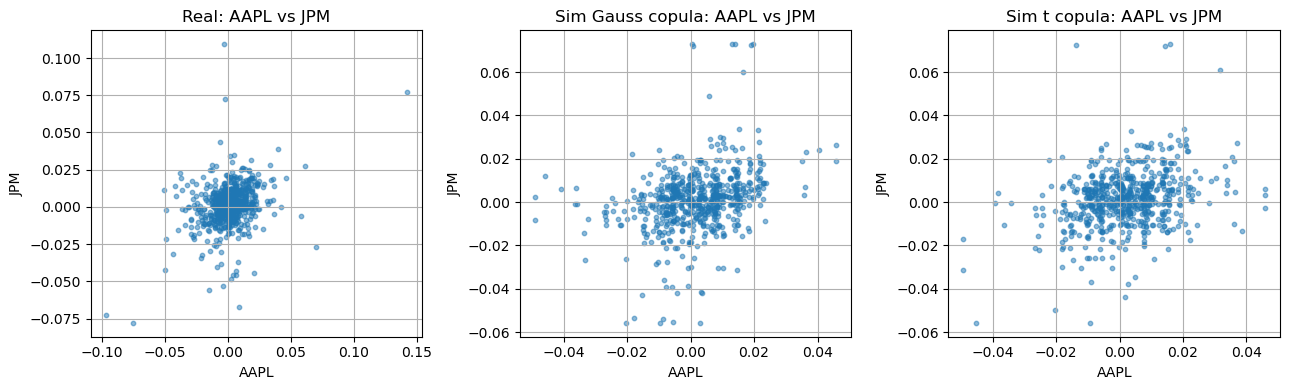

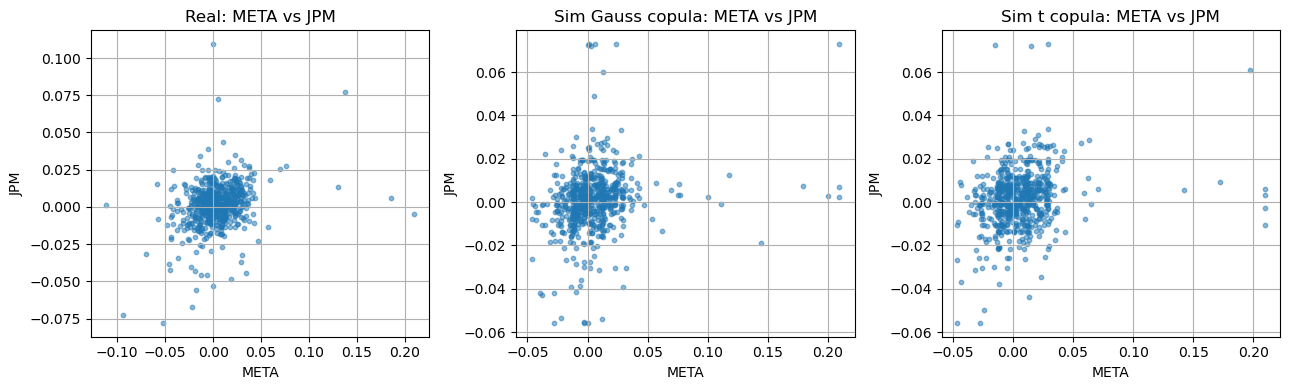

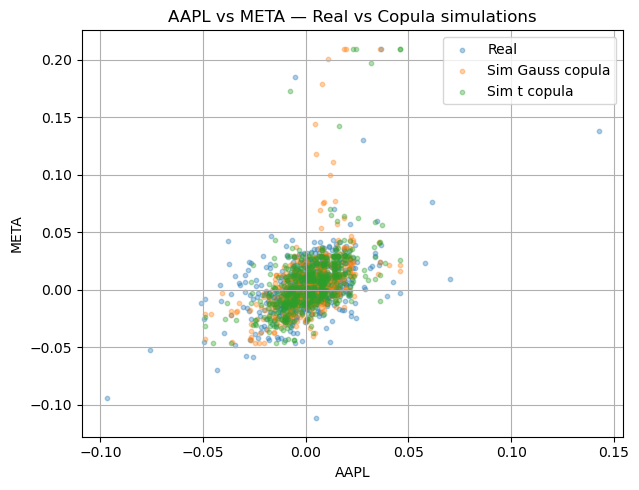

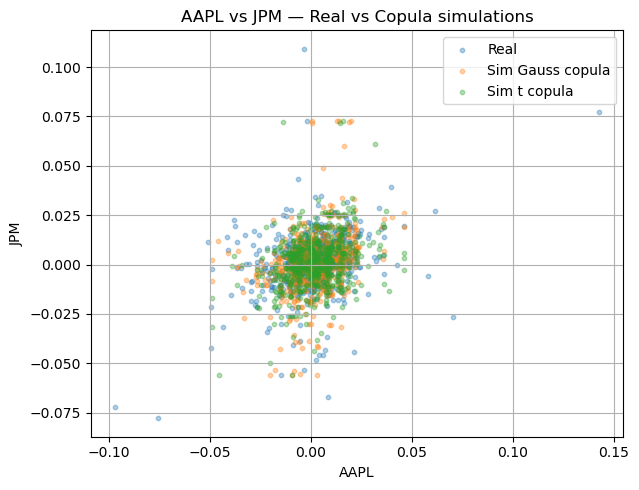

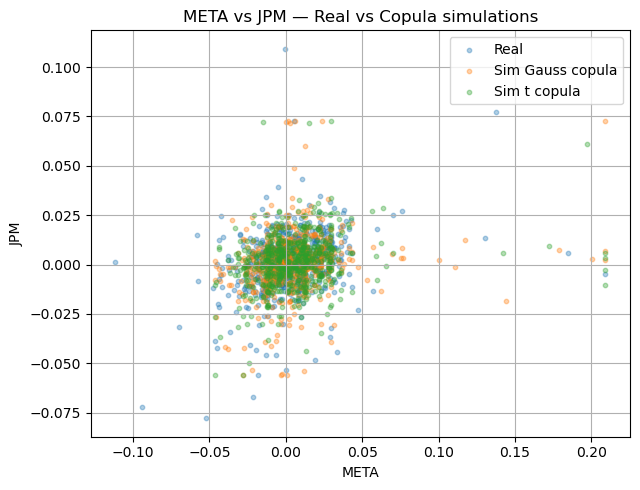

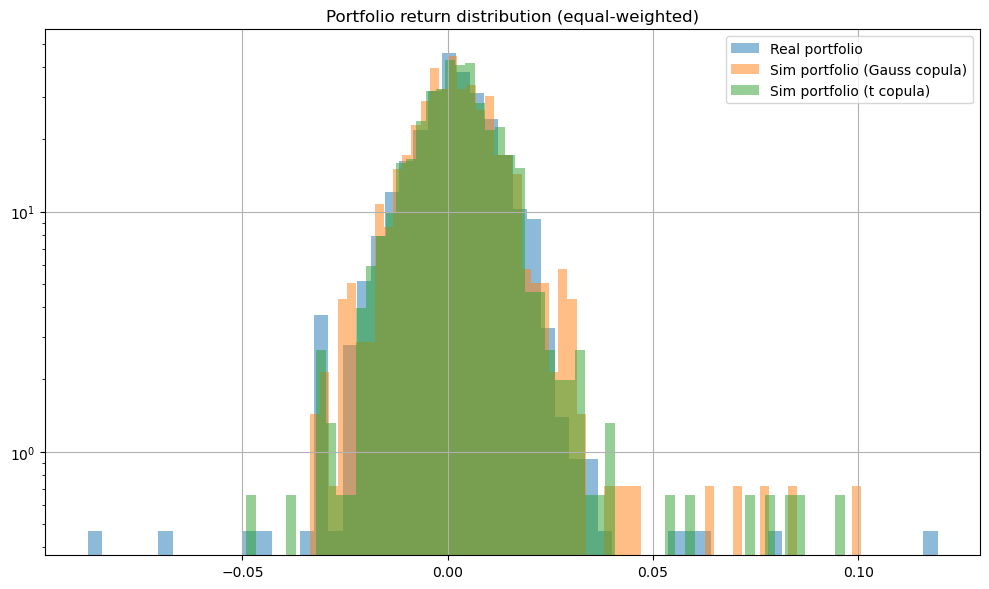

In [47]:
# ============================================
# Q4(c) run
# ============================================
assets = ["AAPL", "META", "JPM"]
W = 252
log_ret_aligned = log_ret[assets].dropna(how="any")

T_total = len(log_ret_aligned) # (total number of observations)
print("T_total =", T_total)

R_sim_g, Rp_sim_g, params_g = simulate_assets_from_fitted_copula_single_window(
    log_ret=log_ret,
    assets=assets,
    W=W,
    copula_kind="gaussian",
    T=T_total,
    seed=123
)

R_sim_t, Rp_sim_t, params_t = simulate_assets_from_fitted_copula_single_window(
    log_ret=log_ret,
    assets=assets,
    W=W,
    copula_kind="student",
    T=T_total,
    seed=123
)

print("Gaussian copula fitted sigma:\n", pd.DataFrame(params_g["sigma"], index=assets, columns=assets))
print("\nStudent-t copula fitted sigma:\n", pd.DataFrame(params_t["sigma"], index=assets, columns=assets))
print("\nStudent-t df:", params_t["df"])

# ============================================
# Visual comparisons: (histograms and scatter)
# ============================================

# comparison of marginal distributions (histograms)
for a in assets:
    plt.figure(figsize=(10, 6))
    plt.hist(log_ret_aligned[a].values, bins=60, alpha=0.5, density=True, log=True, label="Real")
    plt.hist(R_sim_g[a].values, bins=60, alpha=0.5, density=True, log=True, label="Sim (Gauss copula)")
    plt.hist(R_sim_t[a].values, bins=60, alpha=0.5, density=True, log=True, label="Sim (t copula)")
    plt.title(f"Marginal distribution: {a}")
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()

# comparison of dependence on simulated data vs real data (scatter)
for i, j in itertools.combinations(assets, 2):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].scatter(log_ret_aligned[i], log_ret_aligned[j], s=10, alpha=0.5)
    axes[0].set_title(f"Real: {i} vs {j}")
    axes[0].set_xlabel(i); axes[0].set_ylabel(j)
    axes[0].grid(True)

    axes[1].scatter(R_sim_g[i], R_sim_g[j], s=10, alpha=0.5)
    axes[1].set_title(f"Sim Gauss copula: {i} vs {j}")
    axes[1].set_xlabel(i); axes[1].set_ylabel(j)
    axes[1].grid(True)

    axes[2].scatter(R_sim_t[i], R_sim_t[j], s=10, alpha=0.5)
    axes[2].set_title(f"Sim t copula: {i} vs {j}")
    axes[2].set_xlabel(i); axes[2].set_ylabel(j)
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

for i, j in itertools.combinations(assets, 2):
    plt.figure(figsize=(6.5, 5))

    # Real
    plt.scatter(
        log_ret_aligned[i], log_ret_aligned[j],
        s=10, alpha=0.35, label="Real"
    )

    # Sim Gaussian copula
    plt.scatter(
        R_sim_g[i], R_sim_g[j],
        s=10, alpha=0.35, label="Sim Gauss copula"
    )

    # Sim Student-t copula
    plt.scatter(
        R_sim_t[i], R_sim_t[j],
        s=10, alpha=0.35, label="Sim t copula"
    )

    plt.title(f"{i} vs {j} — Real vs Copula simulations")
    plt.xlabel(i)
    plt.ylabel(j)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# comparison btw portfolio total distribution, not just marginals
Rp_real = log_ret_aligned.mean(axis=1).values

plt.figure(figsize=(10, 6))
plt.hist(Rp_real, bins=60, alpha=0.5, density=True, log=True, label="Real portfolio")
plt.hist(Rp_sim_g.values, bins=60, alpha=0.5, density=True, log=True, label="Sim portfolio (Gauss copula)")
plt.hist(Rp_sim_t.values, bins=60, alpha=0.5, density=True, log=True, label="Sim portfolio (t copula)")
plt.title("Portfolio return distribution (equal-weighted)")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


## 5) Portfolio VaR/ES with copulas (rolling)

Equal-weighted portfolio of AAPL, MSFT, JPM. Compare univariate models (as in Exercise 3) vs copula-based VaR/ES with rolling windows.

At each time, fit copulas on last W days, simulate N scenarios, estimate VaR/ES from simulated portfolio returns, then backtest.

## 5.a)

In [49]:
# at this point, we have all the necessary routines, needed for a complete implemented

# -----------------------------
# 5(a) Portfolio returns/losses
# -----------------------------
assets = ["AAPL", "META", "JPM"]
ticker_port = "PORT" # "PORT" meaning portfolio

# Equal-weight portfolio return series (aligned dates)
rp = log_ret[assets].dropna(how="any").mean(axis=1)
log_ret_port = pd.DataFrame({ticker_port: rp})

# -----------------------------
# p_matrix for PORT (again, p=0 everywhere)
# we add a PORT row with 0 for the same columns as p_matrix
# -----------------------------
p_matrix_port = p_matrix.copy()

if ticker_port not in p_matrix_port.index:
    p_matrix_port.loc[ticker_port, :] = 0

# -----------------------------
# Rolling forecasts on PORT using the same routine as in 3)
# -----------------------------
W = 252
conf_level = [0.95, 0.99]

df_port_forecasts = build_rolling_forecasts(
    log_ret=log_ret_port,
    TICKERS=[ticker_port],
    conf_level=conf_level,
    W=W,
    p_matrix=p_matrix_port,
    scale=100.0,
    M_fhs=20000,
    seed_fhs=42,
    quantile_method="weibull",
    store_params=True
)

print(df_port_forecasts.head())
print("df_port_forecasts shape:", df_port_forecasts.shape)
print("Methods:", df_port_forecasts["method"].unique())

        date asset  alpha     method       VaR        ES    L_real    R_real  \
0 2024-01-05  PORT   0.95         HS  0.017722  0.021172 -0.004934  0.004934   
1 2024-01-05  PORT   0.95   Gaussian  0.018675  0.023983 -0.004934  0.004934   
2 2024-01-05  PORT   0.95  Student-t  0.017703  0.025867 -0.004934  0.004934   
3 2024-01-05  PORT   0.95   AR-GARCH  0.011693  0.015116 -0.004934  0.004934   
4 2024-01-05  PORT   0.95        FHS  0.011190  0.014034 -0.004934  0.004934   

   breach                                             params  
0       0  {'sample_losses': [-0.013469452954235529, 0.00...  
1       0  {'mu': -0.002218342627903623, 'sigma': 0.01270...  
2       0  {'nu': 5.345149958534398, 'mu': -0.00180279724...  
3       0  {'mu_next': 0.0017819156256091665, 'sigma_next...  
4       0  {'mu_next': 0.0017819156256091665, 'sigma_next...  
df_port_forecasts shape: (3700, 10)
Methods: ['HS' 'Gaussian' 'Student-t' 'AR-GARCH' 'FHS']

Kupiec (PORT):


,alpha,asset,method,T,N,p0,phat,LR_pof,pvalue_pof
0,0.95,PORT,HS,370,24,0.05,0.064865,1.580101,0.208746
1,0.95,PORT,Gaussian,370,24,0.05,0.064865,1.580101,0.208746
2,0.95,PORT,Student-t,370,27,0.05,0.072973,3.622796,0.056993
3,0.95,PORT,AR-GARCH,370,24,0.05,0.064865,1.580101,0.208746
4,0.95,PORT,FHS,370,23,0.05,0.062162,1.073138,0.300238
5,0.99,PORT,HS,370,7,0.01,0.018919,2.355902,0.124810
6,0.99,PORT,Gaussian,370,13,0.01,0.035135,14.310172,0.000155
7,0.99,PORT,Student-t,370,11,0.01,0.029730,9.516832,0.002036
8,0.99,PORT,AR-GARCH,370,11,0.01,0.029730,9.516832,0.002036
9,0.99,PORT,FHS,370,9,0.01,0.024324,5.477110,0.019267



Christoffersen (PORT):


,alpha,asset,method,T,N,LR_pof,pvalue_pof,n00,n01,n10,n11,p01,p11,LR_ind,pvalue_ind,LR_cc,pvalue_cc
0,0.95,PORT,HS,370,24,1.580101,0.208746,323,22,22,2,0.063768,0.083333,0.131373,0.717012,1.711474,0.424970
1,0.95,PORT,Gaussian,370,24,1.580101,0.208746,324,21,21,3,0.060870,0.125000,1.237005,0.266049,2.817106,0.244497
2,0.95,PORT,Student-t,370,27,3.622796,0.056993,318,24,24,3,0.070175,0.111111,0.546188,0.459880,4.168984,0.124370
3,0.95,PORT,AR-GARCH,370,24,1.580101,0.208746,324,21,21,3,0.060870,0.125000,1.237005,0.266049,2.817106,0.244497
4,0.95,PORT,FHS,370,23,1.073138,0.300238,326,20,20,3,0.057803,0.130435,1.538718,0.214809,2.611856,0.270921
5,0.99,PORT,HS,370,7,2.355902,0.124810,356,6,6,1,0.016575,0.142857,2.534580,0.111377,4.890482,0.086705
6,0.99,PORT,Gaussian,370,13,14.310172,0.000155,344,12,12,1,0.033708,0.076923,0.526274,0.468178,14.836446,0.000600
7,0.99,PORT,Student-t,370,11,9.516832,0.002036,348,10,10,1,0.027933,0.090909,0.973707,0.323757,10.490539,0.005272
8,0.99,PORT,AR-GARCH,370,11,9.516832,0.002036,348,10,10,1,0.027933,0.090909,0.973707,0.323757,10.490539,0.005272
9,0.99,PORT,FHS,370,9,5.477110,0.019267,351,9,9,0,0.025000,0.000000,0.450114,0.502281,5.927224,0.051632



Z1 (PORT):


,alpha,asset,method,Z1_obs,N_obs,pvalue_one_sided,M_requested,M_effective,M_skipped_no_breach,Z1_sim_mean,Z1_sim_std
0,0.95,PORT,HS,0.212968,24,0.003000,1000,1000,0,0.001706,0.066354
1,0.95,PORT,Gaussian,0.380120,24,0.000000,1000,1000,0,-0.000930,0.046187
2,0.95,PORT,Student-t,0.216045,27,0.042000,1000,1000,0,0.001308,0.108961
3,0.95,PORT,AR-GARCH,0.270438,24,0.000000,1000,1000,0,0.000154,0.045574
4,0.95,PORT,FHS,0.190403,23,0.003000,1000,1000,0,0.010301,0.057794
5,0.99,PORT,HS,0.335551,7,0.000000,1000,945,55,-0.000881,0.059421
6,0.99,PORT,Gaussian,0.321476,13,0.004098,1000,976,24,0.001216,0.075742
7,0.99,PORT,Student-t,0.054817,11,0.262834,1000,974,26,0.002474,0.221105
8,0.99,PORT,AR-GARCH,0.247132,11,0.007209,1000,971,29,0.000770,0.074736
9,0.99,PORT,FHS,0.234908,9,0.020661,1000,968,32,0.024997,0.084693


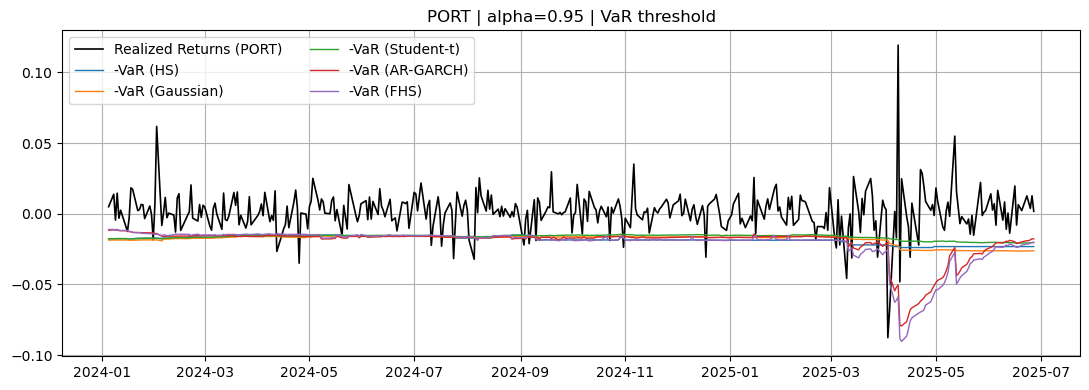

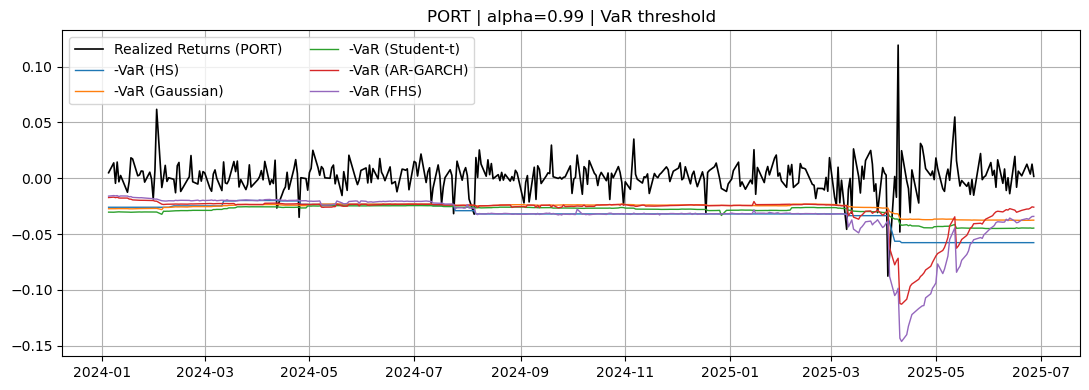

In [52]:
# plotting VaR forecasts along with the realized PORT returns (from df_port_forecasts)
methods = ["HS", "Gaussian", "Student-t", "AR-GARCH", "FHS"]
conf_level_bt = [0.95, 0.99]

ticker_port = "PORT"  # as above

# here we plot -VaR forecasts along with returns
# since VaR_t are compiuted on losses (=-returns)
for alpha_bt in conf_level_bt:
    plt.figure(figsize=(11, 4))

    sub0 = df_port_forecasts[
        (df_port_forecasts["asset"] == ticker_port) &
        (df_port_forecasts["alpha"] == alpha_bt)
    ].sort_values("date")

    if len(sub0) == 0:
        continue

    # R_real is duplicated across methods; keep one point per date for the black line
    sub_real = sub0.drop_duplicates(subset=["date"])

    plt.plot(sub_real["date"], sub_real["R_real"], color="black",
             label="Realized Returns (PORT)", linewidth=1.2)

    for method in methods:
        sub = sub0[sub0["method"] == method].sort_values("date")
        if len(sub) == 0:
            continue
        plt.plot(sub["date"], -sub["VaR"], label=f"-VaR ({method})", linewidth=1.0)

    plt.title(f"{ticker_port} | alpha={alpha_bt} | VaR threshold")
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.grid(True)
    plt.show()


In [ ]:
# ----------------------------------------------------
# Backtesting (Kupiec + Christoffersen + Z1) on PORT
# ----------------------------------------------------
kupiec_rows = []
chris_rows = []
z1_rows = []

for alpha in conf_level:
    for method in df_port_forecasts["method"].unique():
        sub = df_port_forecasts[
            (df_port_forecasts["alpha"] == alpha) &
            (df_port_forecasts["method"] == method)
        ].sort_values("date")

        breaches = sub["breach"].to_numpy(dtype=int)

        # Kupiec
        out_pof = kupiec_pof_test(breaches, alpha)
        kupiec_rows.append({
            "alpha": alpha, "asset": ticker_port, "method": method,
            **out_pof
        })

        # Christoffersen (conditional coverage)
        out_cc = christoffersen_conditional_coverage_test(breaches, alpha=alpha)
        chris_rows.append({
            "alpha": alpha,
            "asset": ticker_port,
            "method": method,
            "T": out_cc["T"],
            "N": out_cc["N"],

            # Unconditional coverage (Kupiec)
            "LR_pof": out_cc["LR_pof"],
            "pvalue_pof": out_cc["pvalue_pof"],

            # Independence
            "n00": out_cc["n00"], "n01": out_cc["n01"], "n10": out_cc["n10"], "n11": out_cc["n11"],
            "p01": out_cc["p01"], "p11": out_cc["p11"],
            "LR_ind": out_cc["LR_ind"],
            "pvalue_ind": out_cc["pvalue_ind"],

            # Joint conditional coverage
            "LR_cc": out_cc["LR_cc"],
            "pvalue_cc": out_cc["pvalue_cc"],
        })

        # Z1 (Acerbi-Szekely) needs the "simulation_*" function of our models
        L_real = sub["L_real"].to_numpy(dtype=float)
        VaR = sub["VaR"].to_numpy(dtype=float)
        ES  = sub["ES"].to_numpy(dtype=float)
        params_list = sub["params"].tolist()

        if method == "HS":
            sim_fun = simulate_hs
        elif method == "Gaussian":
            sim_fun = simulate_gaussian
        elif method == "Student-t":
            sim_fun = simulate_student_t
        elif method == "AR-GARCH":
            sim_fun = simulate_ar_garch_gaussian
        elif method == "FHS":
            sim_fun = simulate_fhs
        else:
            raise ValueError("Unknown method: " + str(method))

        out_z1 = acerbi_szekely_z1_test(
            L_real=L_real,
            VaR=VaR,
            ES=ES,
            params_list=params_list,
            simulate_one_step=sim_fun,
            M=1000,
            seed=123
        )
        z1_rows.append({
            "alpha": alpha, "asset": ticker_port, "method": method,
            **out_z1
        })

kupiec_df_port = pd.DataFrame(kupiec_rows).sort_values(["alpha"]).reset_index(drop=True)
chris_df_port  = pd.DataFrame(chris_rows).sort_values(["alpha"]).reset_index(drop=True)
z1_df_port     = pd.DataFrame(z1_rows).sort_values(["alpha"]).reset_index(drop=True)

print("\nKupiec (PORT):")
display(kupiec_df_port)

print("\nChristoffersen (PORT):")
display(chris_df_port)

print("\nZ1 (PORT):")
display(z1_df_port)

In [69]:
# pass/fail at 5% level
kupiec_df_port["pass_5pct"] = kupiec_df_port["pvalue_pof"] > prim_confid_value

chris_df_port["pass_cc_5pct"]  = chris_df_port["pvalue_cc"]  > prim_confid_value
chris_df_port["pass_pof_5pct"] = chris_df_port["pvalue_pof"] > prim_confid_value
chris_df_port["pass_ind_5pct"] = chris_df_port["pvalue_ind"] > prim_confid_value

z1_df_port["pass_5pct"] = z1_df_port["pvalue_one_sided"] > prim_confid_value



In [70]:
display(kupiec_df_port.loc[:, ["alpha","asset","method","pass_5pct"]])
display(kupiec_df_port.pivot_table(index=["alpha","asset","method"], values="pass_5pct", aggfunc="first", sort=False))


,alpha,asset,method,pass_5pct
0,0.95,PORT,HS,True
1,0.95,PORT,Gaussian,True
2,0.95,PORT,Student-t,True
3,0.95,PORT,AR-GARCH,True
4,0.95,PORT,FHS,True
5,0.99,PORT,HS,True
6,0.99,PORT,Gaussian,False
7,0.99,PORT,Student-t,False
8,0.99,PORT,AR-GARCH,False
9,0.99,PORT,FHS,False


pass_5pct
alpha asset method              
0.95  PORT  HS              True
            Gaussian        True
            Student-t       True
            AR-GARCH        True
            FHS             True
0.99  PORT  HS              True
            Gaussian       False
            Student-t      False
            AR-GARCH       False
            FHS            False

In [71]:
display(chris_df_port.loc[:, ["alpha","asset","method","pass_cc_5pct"]])
display(chris_df_port.pivot_table(index=["alpha","asset","method"], values="pass_cc_5pct", aggfunc="first", sort=False))

,alpha,asset,method,pass_cc_5pct
0,0.95,PORT,HS,True
1,0.95,PORT,Gaussian,True
2,0.95,PORT,Student-t,True
3,0.95,PORT,AR-GARCH,True
4,0.95,PORT,FHS,True
5,0.99,PORT,HS,True
6,0.99,PORT,Gaussian,False
7,0.99,PORT,Student-t,False
8,0.99,PORT,AR-GARCH,False
9,0.99,PORT,FHS,True


pass_cc_5pct
alpha asset method                 
0.95  PORT  HS                 True
            Gaussian           True
            Student-t          True
            AR-GARCH           True
            FHS                True
0.99  PORT  HS                 True
            Gaussian          False
            Student-t         False
            AR-GARCH          False
            FHS                True

In [72]:
display(z1_df_port.loc[:, ["alpha","asset","method","pass_5pct"]])
display(z1_df_port.pivot_table(index=["alpha","asset","method"], values="pass_5pct", aggfunc="first", sort=False))

,alpha,asset,method,pass_5pct
0,0.95,PORT,HS,False
1,0.95,PORT,Gaussian,False
2,0.95,PORT,Student-t,False
3,0.95,PORT,AR-GARCH,False
4,0.95,PORT,FHS,False
5,0.99,PORT,HS,False
6,0.99,PORT,Gaussian,False
7,0.99,PORT,Student-t,True
8,0.99,PORT,AR-GARCH,False
9,0.99,PORT,FHS,False


pass_5pct
alpha asset method              
0.95  PORT  HS             False
            Gaussian       False
            Student-t      False
            AR-GARCH       False
            FHS            False
0.99  PORT  HS             False
            Gaussian       False
            Student-t       True
            AR-GARCH       False
            FHS            False

## Compact&Visual results of backtests

In [73]:
# we provide here the same visual resumed result as in part 3 fair univariate analysis

# merging tables (keep only what we need)
k_port = kupiec_df_port[["alpha", "asset", "method", "pvalue_pof", "pass_5pct"]].rename(
    columns={"pvalue_pof": "p_kupiec", "pass_5pct": "kupiec_pass"}
)

c_port = chris_df_port[["alpha", "asset", "method", "pvalue_cc", "pass_cc_5pct"]].rename(
    columns={"pvalue_cc": "p_chris_cc", "pass_cc_5pct": "chris_cc_pass"}
)

z_port = z1_df_port[["alpha", "asset", "method", "pvalue_one_sided", "pass_5pct", "N_obs"]].rename(
    columns={"pvalue_one_sided": "p_z1", "pass_5pct": "z1_pass", "N_obs": "N_obs_z1"}
)

summary_port = (
    k_port.merge(c_port, on=["alpha", "asset", "method"], how="outer")
     .merge(z_port, on=["alpha", "asset", "method"], how="outer")
)

# color cells to display visually
def fmt_cell(p, passed, label="p"):
    if pd.isna(passed):
        return "⚪ (inconcl.)"
    if pd.isna(p):
        return "⚪ (p=NaN)"
    return ("🟢 " if bool(passed) else "🔴 ") + f"({label}={p:.3f})"

summary_port["Kupiec"] = [fmt_cell(p, b, "p") for p, b in zip(summary_port["p_kupiec"], summary_port["kupiec_pass"])]
summary_port["Chris-CC"] = [fmt_cell(p, b, "p") for p, b in zip(summary_port["p_chris_cc"], summary_port["chris_cc_pass"])]
summary_port["Z1 (one-sided)"] = [fmt_cell(p, b, "p") for p, b in zip(summary_port["p_z1"], summary_port["z1_pass"])]

# simple score (count only available tests)
summary_port["score_total"] = (
    summary_port["kupiec_pass"].fillna(False).astype(int) +
    summary_port["chris_cc_pass"].fillna(False).astype(int) +
    summary_port["z1_pass"].fillna(0).astype(int)
)

summary_port["tests_counted"] = (
    summary_port["kupiec_pass"].notna().astype(int) +
    summary_port["chris_cc_pass"].notna().astype(int) +
    summary_port["z1_pass"].notna().astype(int)
)

# final compact display and visual table
scorecard_port = summary_port[[
    "alpha", "asset", "method",
    "Kupiec", "Chris-CC", "Z1 (one-sided)",
    "score_total", "tests_counted", "N_obs_z1"
]]

scorecard_port



,alpha,asset,method,Kupiec,Chris-CC,Z1 (one-sided),score_total,tests_counted,N_obs_z1
0,0.95,PORT,AR-GARCH,🟢 (p=0.209),🟢 (p=0.244),🔴 (p=0.000),2,3,24
1,0.95,PORT,FHS,🟢 (p=0.300),🟢 (p=0.271),🔴 (p=0.003),2,3,23
2,0.95,PORT,Gaussian,🟢 (p=0.209),🟢 (p=0.244),🔴 (p=0.000),2,3,24
3,0.95,PORT,HS,🟢 (p=0.209),🟢 (p=0.425),🔴 (p=0.003),2,3,24
4,0.95,PORT,Student-t,🟢 (p=0.057),🟢 (p=0.124),🔴 (p=0.042),2,3,27
5,0.99,PORT,AR-GARCH,🔴 (p=0.002),🔴 (p=0.005),🔴 (p=0.007),0,3,11
6,0.99,PORT,FHS,🔴 (p=0.019),🟢 (p=0.052),🔴 (p=0.021),1,3,9
7,0.99,PORT,Gaussian,🔴 (p=0.000),🔴 (p=0.001),🔴 (p=0.004),0,3,13
8,0.99,PORT,HS,🟢 (p=0.125),🟢 (p=0.087),🔴 (p=0.000),2,3,7
9,0.99,PORT,Student-t,🔴 (p=0.002),🔴 (p=0.005),🟢 (p=0.263),1,3,11


## 5.b),c)

In [57]:
# ============================================
# Rolling copula forecasts on portfolio
# ============================================

assets = ["AAPL", "META", "JPM"]
W = 252
conf_level = [0.95, 0.99]
N_cop = 1000
seed_cop = 123

# Rolling forecasts for Gaussian copula
df_cop_gauss = build_rolling_forecasts_portfolio_copula(
    log_ret=log_ret,
    assets=assets,
    W=W,
    alphas=conf_level,
    copula_kind="gaussian",
    N=N_cop,
    seed=seed_cop,
    quantile_method="weibull",
    store_params=True
)

# Rolling forecasts for Student-t copula
df_cop_student = build_rolling_forecasts_portfolio_copula(
    log_ret=log_ret,
    assets=assets,
    W=W,
    alphas=conf_level,
    copula_kind="student",
    N=N_cop,
    seed=seed_cop,
    quantile_method="weibull",
    store_params=True
)

# Merge the two copula outputs
df_cop_forecasts = pd.concat([df_cop_gauss, df_cop_student], ignore_index=True)
df_cop_forecasts.sort_values(["alpha"], inplace=True)
df_cop_forecasts.reset_index(drop=True, inplace=True)

print(df_cop_forecasts.head())
print("df_cop_forecasts shape:", df_cop_forecasts.shape)
print("Copula methods:", df_cop_forecasts["method"].unique())

/Users/timo/anaconda3/lib/python3.11/site-packages/scipy/optimize/_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/Users/timo/anaconda3/lib/python3.11/site-packages/copulae/stats/_multivariate_t.py:116: RuntimeWarning: overflow encountered in power
  c = np.diag(1 + (x_us @ la.inv(cov) @ x_us.T) / df) ** ((dim + df) / 2)
/Users/timo/anaconda3/lib/python3.11/site-packages/copulae/stats/_multivariate_t.py:79: RuntimeWarning: divide by zero encountered in log
  return np.log(cls.pdf(x, mean, cov, df))
/Users/timo/anaconda3/lib/python3.11/site-packages/scipy/optimize/_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/Users/timo/anaconda3/lib/python3.11/site-packages/copulae/stats/_multivariate_t.py:116: RuntimeWarning: overflow encountered in power
  c = np.diag(1 + (x_us @ la.inv(cov) @ x_us.T) / df) ** ((dim + df) / 2)
/Users/

        date asset           method  alpha       VaR        ES    R_real  \
0 2024-02-15  PORT  Copula-Gaussian   0.95  0.017473  0.022698  0.014154   
1 2024-02-16  PORT  Copula-Gaussian   0.95  0.017091  0.022186 -0.011841   
2 2024-02-20  PORT  Copula-Gaussian   0.95  0.017018  0.022207 -0.001181   
3 2024-02-21  PORT  Copula-Gaussian   0.95  0.016019  0.023342  0.001270   
4 2024-02-22  PORT  Copula-Gaussian   0.95  0.015474  0.021180  0.020350   

     L_real  breach                                             params  
0 -0.014154       0  {'assets': ['AAPL', 'META', 'JPM'], 'copula_ki...  
1  0.011841       0  {'assets': ['AAPL', 'META', 'JPM'], 'copula_ki...  
2  0.001181       0  {'assets': ['AAPL', 'META', 'JPM'], 'copula_ki...  
3 -0.001270       0  {'assets': ['AAPL', 'META', 'JPM'], 'copula_ki...  
4 -0.020350       0  {'assets': ['AAPL', 'META', 'JPM'], 'copula_ki...  
df_cop_forecasts shape: (1480, 10)
Copula methods: ['Copula-Gaussian' 'Copula-Student']


In [58]:
# ============================================
# Backtesting on copula forecasts (PORT)
# Kupiec, Christoffersen and Z1
# ============================================

kupiec_rows_cop = []
chris_rows_cop = []
z1_rows_cop = []

for alpha in conf_level:
    for method in df_cop_forecasts["method"].unique():
        sub = df_cop_forecasts[
            (df_cop_forecasts["alpha"] == alpha) &
            (df_cop_forecasts["method"] == method)
        ].sort_values("date")

        breaches = sub["breach"].to_numpy(dtype=int)

        # Kupiec
        out_pof = kupiec_pof_test(breaches, alpha)
        kupiec_rows_cop.append({
            "asset": "PORT", "method": method, "alpha": alpha,
            **out_pof
        })

        # Christoffersen
        out_cc = christoffersen_conditional_coverage_test(breaches, alpha=alpha)
        chris_rows_cop.append({
            "asset": "PORT",
            "method": method,
            "alpha": alpha,
            "T": out_cc["T"],
            "N": out_cc["N"],

            "LR_pof": out_cc["LR_pof"],
            "pvalue_pof": out_cc["pvalue_pof"],

            "n00": out_cc["n00"], "n01": out_cc["n01"], "n10": out_cc["n10"], "n11": out_cc["n11"],
            "p01": out_cc["p01"], "p11": out_cc["p11"],
            "LR_ind": out_cc["LR_ind"],
            "pvalue_ind": out_cc["pvalue_ind"],
            "LR_cc": out_cc["LR_cc"],
            "pvalue_cc": out_cc["pvalue_cc"],
        })

        # Z1 (Acerbi–Szekely) for ES
        L_real = sub["L_real"].to_numpy(dtype=float)
        VaR = sub["VaR"].to_numpy(dtype=float)
        ES  = sub["ES"].to_numpy(dtype=float)
        params_list = sub["params"].tolist()

        # for both copula methods, same simulate function:
        sim_fun = simulate_copula_portfolio

        out_z1 = acerbi_szekely_z1_test(
            L_real=L_real,
            VaR=VaR,
            ES=ES,
            params_list=params_list,
            simulate_one_step=sim_fun,
            M=1000,
            seed=123
        )

        z1_rows_cop.append({
            "asset": "PORT", "method": method, "alpha": alpha,
            **out_z1
        })

kupiec_df_cop = pd.DataFrame(kupiec_rows_cop).sort_values(["alpha"]).reset_index(drop=True)
chris_df_cop  = pd.DataFrame(chris_rows_cop).sort_values(["alpha"]).reset_index(drop=True)
z1_df_cop     = pd.DataFrame(z1_rows_cop).sort_values(["alpha"]).reset_index(drop=True)

print("\nKupiec (COPULA PORTFOLIO):")
display(kupiec_df_cop)

print("\nChristoffersen (COPULA PORTFOLIO):")
display(chris_df_cop)

print("\nZ1 (COPULA PORTFOLIO):")
display(z1_df_cop)


Kupiec (COPULA PORTFOLIO):


,asset,method,alpha,T,N,p0,phat,LR_pof,pvalue_pof
0,PORT,Copula-Gaussian,0.95,370,24,0.05,0.064865,1.580101,0.208746
1,PORT,Copula-Student,0.95,370,24,0.05,0.064865,1.580101,0.208746
2,PORT,Copula-Gaussian,0.99,370,8,0.01,0.021622,3.788416,0.051608
3,PORT,Copula-Student,0.99,370,5,0.01,0.013514,0.415670,0.519106



Christoffersen (COPULA PORTFOLIO):


,asset,method,alpha,T,N,LR_pof,pvalue_pof,n00,n01,n10,n11,p01,p11,LR_ind,pvalue_ind,LR_cc,pvalue_cc
0,PORT,Copula-Gaussian,0.95,370,24,1.580101,0.208746,323,22,22,2,0.063768,0.083333,0.131373,0.717012,1.711474,0.424970
1,PORT,Copula-Student,0.95,370,24,1.580101,0.208746,323,22,22,2,0.063768,0.083333,0.131373,0.717012,1.711474,0.424970
2,PORT,Copula-Gaussian,0.99,370,8,3.788416,0.051608,354,7,7,1,0.019391,0.125000,2.033781,0.153838,5.822197,0.054416
3,PORT,Copula-Student,0.99,370,5,0.415670,0.519106,360,4,4,1,0.010989,0.200000,3.898783,0.048321,4.314453,0.115645



Z1 (COPULA PORTFOLIO):


,asset,method,alpha,Z1_obs,N_obs,pvalue_one_sided,M_requested,M_effective,M_skipped_no_breach,Z1_sim_mean,Z1_sim_std
0,PORT,Copula-Gaussian,0.95,0.211377,24,0.014000,1000,1000,0,0.011818,0.081677
1,PORT,Copula-Student,0.95,0.155330,24,0.053000,1000,1000,0,0.006709,0.085823
2,PORT,Copula-Gaussian,0.99,0.104471,8,0.196939,1000,980,20,0.026043,0.113102
3,PORT,Copula-Student,0.99,0.253294,5,0.047910,1000,981,19,0.022583,0.133522


In [74]:
# pass/fail at 5% level
kupiec_df_cop["pass_5pct"] = kupiec_df_cop["pvalue_pof"] > prim_confid_value

chris_df_cop["pass_cc_5pct"]  = chris_df_cop["pvalue_cc"]  > prim_confid_value
chris_df_cop["pass_pof_5pct"] = chris_df_cop["pvalue_pof"] > prim_confid_value
chris_df_cop["pass_ind_5pct"] = chris_df_cop["pvalue_ind"] > prim_confid_value

z1_df_cop["pass_5pct"] = z1_df_cop["pvalue_one_sided"] > prim_confid_value

In [75]:
display(kupiec_df_cop.loc[:, ["alpha","asset","method","pass_5pct"]])
display(kupiec_df_cop.pivot_table(index=["alpha","asset","method"], values="pass_5pct", aggfunc="first", sort=False))


,alpha,asset,method,pass_5pct
0,0.95,PORT,Copula-Gaussian,True
1,0.95,PORT,Copula-Student,True
2,0.99,PORT,Copula-Gaussian,True
3,0.99,PORT,Copula-Student,True


pass_5pct
alpha asset method                    
0.95  PORT  Copula-Gaussian       True
            Copula-Student        True
0.99  PORT  Copula-Gaussian       True
            Copula-Student        True

In [76]:
display(chris_df_cop.loc[:, ["alpha","asset","method","pass_cc_5pct"]])
display(chris_df_cop.pivot_table(index=["alpha","asset","method"], values="pass_cc_5pct", aggfunc="first", sort=False))

,alpha,asset,method,pass_cc_5pct
0,0.95,PORT,Copula-Gaussian,True
1,0.95,PORT,Copula-Student,True
2,0.99,PORT,Copula-Gaussian,True
3,0.99,PORT,Copula-Student,True


pass_cc_5pct
alpha asset method                       
0.95  PORT  Copula-Gaussian          True
            Copula-Student           True
0.99  PORT  Copula-Gaussian          True
            Copula-Student           True

In [77]:
display(z1_df_cop.loc[:, ["alpha","asset","method","pass_5pct"]])
display(z1_df_cop.pivot_table(index=["alpha","asset","method"], values="pass_5pct", aggfunc="first", sort=False))

,alpha,asset,method,pass_5pct
0,0.95,PORT,Copula-Gaussian,False
1,0.95,PORT,Copula-Student,True
2,0.99,PORT,Copula-Gaussian,True
3,0.99,PORT,Copula-Student,False


pass_5pct
alpha asset method                    
0.95  PORT  Copula-Gaussian      False
            Copula-Student        True
0.99  PORT  Copula-Gaussian       True
            Copula-Student       False

In [79]:
# we provide here the same visual resumed result as in part 3 fair univariate analysis

# merging tables (keep only what we need)
k_cop = kupiec_df_cop[["alpha", "asset", "method", "pvalue_pof", "pass_5pct"]].rename(
    columns={"pvalue_pof": "p_kupiec", "pass_5pct": "kupiec_pass"}
)

c_cop = chris_df_cop[["alpha", "asset", "method", "pvalue_cc", "pass_cc_5pct"]].rename(
    columns={"pvalue_cc": "p_chris_cc", "pass_cc_5pct": "chris_cc_pass"}
)

z_cop = z1_df_cop[["alpha", "asset", "method", "pvalue_one_sided", "pass_5pct", "N_obs"]].rename(
    columns={"pvalue_one_sided": "p_z1", "pass_5pct": "z1_pass", "N_obs": "N_obs_z1"}
)

summary_cop = (
    k_cop.merge(c_cop, on=["alpha", "asset", "method"], how="outer")
     .merge(z_cop, on=["alpha", "asset", "method"], how="outer")
)

# color cells to display visually
def fmt_cell(p, passed, label="p"):
    if pd.isna(passed):
        return "⚪ (inconcl.)"
    if pd.isna(p):
        return "⚪ (p=NaN)"
    return ("🟢 " if bool(passed) else "🔴 ") + f"({label}={p:.3f})"

summary_cop["Kupiec"] = [fmt_cell(p, b, "p") for p, b in zip(summary_cop["p_kupiec"], summary_cop["kupiec_pass"])]
summary_cop["Chris-CC"] = [fmt_cell(p, b, "p") for p, b in zip(summary_cop["p_chris_cc"], summary_cop["chris_cc_pass"])]
summary_cop["Z1 (one-sided)"] = [fmt_cell(p, b, "p") for p, b in zip(summary_cop["p_z1"], summary_cop["z1_pass"])]

# simple score (count only available tests)
summary_cop["score_total"] = (
    summary_cop["kupiec_pass"].fillna(False).astype(int) +
    summary_cop["chris_cc_pass"].fillna(False).astype(int) +
    summary_cop["z1_pass"].fillna(0).astype(int)
)

summary_cop["tests_counted"] = (
    summary_cop["kupiec_pass"].notna().astype(int) +
    summary_cop["chris_cc_pass"].notna().astype(int) +
    summary_cop["z1_pass"].notna().astype(int)
)

# final compact & visual display table
scorecard_cop = summary_cop[[
    "alpha", "asset", "method",
    "Kupiec", "Chris-CC", "Z1 (one-sided)",
    "score_total", "tests_counted", "N_obs_z1"
]]

scorecard_cop



,alpha,asset,method,Kupiec,Chris-CC,Z1 (one-sided),score_total,tests_counted,N_obs_z1
0,0.95,PORT,Copula-Gaussian,🟢 (p=0.209),🟢 (p=0.425),🔴 (p=0.014),2,3,24
1,0.95,PORT,Copula-Student,🟢 (p=0.209),🟢 (p=0.425),🟢 (p=0.053),3,3,24
2,0.99,PORT,Copula-Gaussian,🟢 (p=0.052),🟢 (p=0.054),🟢 (p=0.197),3,3,8
3,0.99,PORT,Copula-Student,🟢 (p=0.519),🟢 (p=0.116),🔴 (p=0.048),2,3,5
